## ICIJ : Comment étudier l'évasion fiscal grâce aux graphes 

In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import networkx as nx
from networkx.algorithms.components import node_connected_component
import community as community_louvain
from collections import defaultdict
from collections import Counter

In [38]:
# Définition des colonnes à utiliser pour chaque type de nœud et relation


use_cols_entities = [
    "node_id",          # ID unique (str)
    "name",             # Nom de l'entreprise
    "jurisdiction",     # Code du pays (ex: "PA" pour Panama)
    "jurisdiction_description",  # Nom complet (ex: "Panama")
    "company_type",     # Type d'entité (ex: "Offshore Company")
    "incorporation_date",  # Date de création (à convertir en datetime)
    "status",           # Statut (ex: "Active", "Inactive")
    "country_codes",    # Codes pays (ex: "PA", "KY" pour Cayman Islands)
    "countries",        # Noms de pays (ex: "Panama")
    "service_provider", # Prestataire (ex: "Mossack Fonseca" → indicateur fort)
    "sourceID"          # Source (ex: "Panama Papers")
]

use_cols_addresses = [
    "node_id",          # ID de l'adresse
    "name",             # Adresse complète
    "country_codes",    # Codes pays (ex: "KY" pour Cayman Islands)
    "countries"         # Noms de pays
]

use_cols_officers = [
    "node_id",          # ID du dirigeant
    "name",             # Nom complet
    "country_codes",    # Pays de résidence
    "countries"
]

use_cols_intermediaries = [
    "node_id",
    "name",
    "country_codes",
    "countries"
]

use_cols_relationships = [
    "node_id_start",    # ID du nœud source (str)
    "node_id_end",      # ID du nœud cible (str)
    "rel_type",         # Type de relation (ex: "registered_address", "officer")
    "start_date",       # Date de début (à convertir en datetime)
    "end_date",         # Date de fin
    "status",           # Statut (ex: "Active")
    "sourceID"          # Source (ex: "Panama Papers")
]

In [39]:
# Chargement des données avec les colonnes spécifiées

nodes_entities = pd.read_csv(
    "nodes-entities.csv",
    dtype={"node_id": "str"},
    usecols=use_cols_entities,
    parse_dates=["incorporation_date"],  # Conversion automatique en datetime
    dayfirst=True  # Pour les dates au format "JJ-MMM-AAAA"
)

nodes_addresses = pd.read_csv(
    "nodes-addresses.csv",
    dtype={"node_id": "str"},
    usecols=use_cols_addresses
)

nodes_officers = pd.read_csv(
    "nodes-officers.csv",
    dtype={"node_id": "str"},
    usecols=use_cols_officers
)

nodes_intermediaries = pd.read_csv(
    "nodes-intermediaries.csv",
    dtype={"node_id": "str"},
    usecols=use_cols_intermediaries
)

relationships = pd.read_csv(
    "relationships.csv",
    dtype={"node_id_start": "str", "node_id_end": "str"},
    usecols=use_cols_relationships,
    parse_dates=["start_date", "end_date"],
    dayfirst=True
)


/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_35825/2325500117.py:3: DtypeWarning: Columns (6,13,14,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  nodes_entities = pd.read_csv(
/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_35825/2325500117.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  nodes_entities = pd.read_csv(
/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_35825/2325500117.py:29: DtypeWarning: Columns (4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  relationships = pd.read_csv(
/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_35825/2325500117.py:29: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a f

## Création du Graphe

In [40]:

# Initialiser un graphe orienté
G = nx.DiGraph()

# --- AJOUTER LES NŒUDS ---

# 1. Nœuds "entités" (nodes-entities.csv)
for _, row in nodes_entities.iterrows():
    G.add_node(
        row["node_id"],
        type="entity",
        name=row["name"],
        jurisdiction=row["jurisdiction"],
        jurisdiction_description=row["jurisdiction_description"],
        country_codes=row["country_codes"],
        company_type=row["company_type"],
        status=row["status"],
        sourceID=row["sourceID"] if "sourceID" in row else None
    )

# 2. Nœuds "adresses" (nodes-addresses.csv)
for _, row in nodes_addresses.iterrows():
    G.add_node(
        row["node_id"],
        type="address",
        name=row["name"],
        country_codes=row.get("country_codes"),
        countries=row.get("countries")
    )

# 3. Nœuds "dirigeants" (nodes-officers.csv)
for _, row in nodes_officers.iterrows():
    G.add_node(
        row["node_id"],
        type="officer",
        name=row["name"],
        country_codes=row.get("country_codes"),
        countries=row.get("countries")
    )

# 4. Nœuds "intermédiaires" (nodes-intermediaries.csv)
for _, row in nodes_intermediaries.iterrows():
    G.add_node(
        row["node_id"],
        type="intermediary",
        name=row["name"],
        country_codes=row.get("country_codes"),
        countries=row.get("countries")
    )


# --- AJOUTER LES RELATIONS --- (relationships.csv)
for _, row in relationships.iterrows():
    G.add_edge(
        row["node_id_start"],
        row["node_id_end"],
        rel_type=row["rel_type"],
        status=row.get("status"),
        sourceID=row.get("sourceID")
    )

print(f"Graphe construit avec {G.number_of_nodes()} nœuds et {G.number_of_edges()} relations.")


Graphe construit avec 2016523 nœuds et 2897134 relations.


In [53]:
import networkx as nx

cok_nodes_in_graph = set()
for node_id, attributes in G.nodes(data=True):
    country_codes_str = str(attributes.get("country_codes", ""))
    if "BLZ" in country_codes_str.split(";"):
        cok_nodes_in_graph.add(node_id)

print(f"Nœuds BLZ dans le graphe : {len(cok_nodes_in_graph)}")

if not cok_nodes_in_graph:
    print("Aucun nœud MHL trouvé.")
else:
    all_nodes_in_cok_components = set()
    for component in nx.weakly_connected_components(G):
        if any(cok_node in component for cok_node in cok_nodes_in_graph):
            all_nodes_in_cok_components.update(component)

    if all_nodes_in_cok_components:
        subgraph_cook_connections = G.subgraph(all_nodes_in_cok_components)
        print(f"Sous-graphe COK : {subgraph_cook_connections.number_of_nodes()} nœuds, {subgraph_cook_connections.number_of_edges()} arêtes.")
    else:
        print("Aucune composante connectée à un nœud COK trouvée.")


Nœuds BLZ dans le graphe : 2848
Sous-graphe COK : 1718570 nœuds, 2610046 arêtes.


In [55]:
# Calcul du pourcentage de nœuds de degré 1 dans le graphe global
degree_one_count = sum(1 for n in subgraph_cook_connections.nodes() if subgraph_cook_connections.degree(n) == 1)
total_nodes = subgraph_cook_connections.number_of_nodes()
proportion_degree_one = (degree_one_count / total_nodes) * 100 if total_nodes > 0 else 0
print(f"Proportion de nœuds de degré 1 dans le sous-graphe COK : {proportion_degree_one:.2f}%")

Proportion de nœuds de degré 1 dans le sous-graphe COK : 39.31%


## 1/ Traitement du graphe

Avant de commencer l'étude, il imcombe de réaliser certains traitements préliminaires 

In [56]:
# On spupprime les noeuds de degré 0

low_degree_nodes = [node for node in G.nodes() if G.degree(node) == 0]
G.remove_nodes_from(low_degree_nodes)

print(f"Graphe après suppression des nœuds de faible degré : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes.")

Graphe après suppression des nœuds de faible degré : 2016165 nœuds, 2897134 arêtes.


In [57]:
#Calcul du nombre de tringles dans le graphe
triangles = sum(nx.triangles(G).values()) // 3
print(f"Nombre de triangles dans le graphe : {triangles}")

NetworkXNotImplemented: not implemented for directed type

In [43]:
# Définition des paradis fiscaux (codes ISO)

paradis_fiscaux = {
    # ⭐⭐⭐ Paradis fiscaux notoires (liste noire UE/OCDE + ICIJ)
    "AIA": "Anguilla",
    "BMU": "Bermudes",
    "VGB": "Îles Vierges britanniques",
    "CYM": "Îles Caïmans",
    "GIB": "Gibraltar",
    "JEY": "Jersey",
    "GGY": "Guernesey",  # Ajouté car souvent utilisé comme paradis fiscal (bien que sous Royaume-Uni)
    "MCO": "Monaco",
    "PAN": "Panama",
    "SGP": "Singapour",
    "CHE": "Suisse",
    "HKG": "Hong Kong",
    "MAC": "Macao",
    "KNA": "Saint-Christophe-et-Niévès",
    "LCA": "Sainte-Lucie",
    "VCT": "Saint-Vincent-et-les-Grenadines",
    "WSM": "Samoa",
    "BHR": "Bahrein",
    "ARE": "Émirats arabes unis",
    "QAT": "Qatar",
    "BHS": "Bahamas",
    "BRB": "Barbade",
    "BLZ": "Belize",
    "CUR": "Curaçao",  # Pays-Bas caribéens
    "ABW": "Aruba",
    "SXM": "Saint-Martin (partie néerlandaise)",
    "BES": "Bonaire, Saint-Eustache et Saba",
    "VUT": "Vanuatu",
    "TON": "Tonga",
    "MHL": "Îles Marshall",
    "FSM": "États fédérés de Micronésie",  # Si présent dans votre graphe
    "PLW": "Palaos",
    "SLB": "Îles Salomon",
    "FLK": "Îles Malouines",  # Rarement utilisé mais parfois cité
    "COK": "Îles Cook",  # Paradis fiscal du Pacifique
    "NIU": "Niue",
    "NFK": "Île Norfolk",

    # ⭐⭐ Paradis fiscaux "passe-plats" (optimisation fiscale légale)
    "NLD": "Pays-Bas",  # Sandwich néerlandais
    "IRL": "Irlande",  # Double Irish
    "LUX": "Luxembourg",
    "CYP": "Chypre",
    "MLT": "Malte",
    "AND": "Andorre",
    "LIE": "Liechtenstein",
    "SMR": "Saint-Marin",



    # 🇺🇸 États/juridictions offshore aux USA (à ajouter si pertinent)
    "USA-DE": "Delaware",  # Code non-standard, mais souvent utilisé comme paradis fiscal interne
    "USA-WY": "Wyoming",
    "USA-NV": "Nevada",

    # 🇬🇧 Juridictions offshore britanniques
    "VGB": "Îles Vierges britanniques",  # Déjà présent
    "CYM": "Îles Caïmans",  # Déjà présent
    "MSR": "Montserrat",
    "SHN": "Sainte-Hélène",  # Rarement utilisé
    "PCN": "Îles Pitcairn",

}

# Liste des codes ISO pour une recherche rapide
paradis_fiscaux_codes = set(paradis_fiscaux.keys())

# Liste des noms complets (pour correspondre aux noms dans votre graphe)
paradis_fiscaux_noms = set(paradis_fiscaux.values())

# Ajout des noms alternatifs (ex : "Curaçao" vs "Curacao")
paradis_fiscaux_noms.update([
    "Curacao", "Curaçao",  # Variantes orthographiques
    "Bolivarian Republic of Venezuela",  # Nom officiel
    "Venezuelan Bolivarian Republic",
    "Brunei Darussalam",  # Variantes
    "Côte d'Ivoire",  # Présent dans votre graphe
    "Democratic Republic of the Congo",  # Pour "COD"
    "Republic of Korea",  # "KOR"
    "United States Minor Outlying Islands",  # Paradis fiscal méconnu
    "British Virgin Islands",  # Équivalent de "VGB"
    "U.S. Virgin Islands",  # Équivalent de "VIR" (si présent)
    "Taiwan", "Province of China Taiwan",  # Cas particulier
    "State of Palestine",
    "Russian Federation",
    "Bahamas"  # Équivalent de "RUS"
    "Vatican City",  # Si présent (non listé ici mais parfois utilisé)
])


In [67]:
# Fonction de résumé du graphe

def resume_graphe(G, type_node_attr='type', type_edge_attr='relation'):
    """
    Affiche un résumé complet d'un graphe NetworkX.
    
    Args:
        G (nx.Graph ou nx.DiGraph): Le graphe à analyser.
        type_node_attr (str): Le nom de l'attribut qui définit le type de noeud (ex: 'entity_type', 'label').
                               Si inconnu, le script essaiera de deviner ou affichera les clés disponibles.
        type_edge_attr (str): Le nom de l'attribut qui définit le type de relation (ex: 'role', 'type').
    """
    print("-" * 30)
    print("📊 RÉSUMÉ DU GRAPHE")
    print("-" * 30)

    # 1. Volumétrie de base
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    print(f"🔹 Nombre total de noeuds : {n_nodes}")
    print(f"🔹 Nombre total d'arêtes : {n_edges}")
    
    # Densité
    density = nx.density(G)
    print(f"🔹 Densité du graphe     : {density:.6f}")
    
    # Composantes connexes (si le graphe n'est pas dirigé ou faiblement connexe pour dirigé)
    if G.is_directed():
        n_components = nx.number_weakly_connected_components(G)
        print(f"🔹 Composantes connexes (faibles) : {n_components}")
    else:
        n_components = nx.number_connected_components(G)
        print(f"🔹 Composantes connexes : {n_components}")

    print("\n" + "-" * 30)
    print("🏷️  ATTRIBUTS ET LABELS")
    print("-" * 30)

    if n_nodes > 0:
        # Récupérer un noeud exemple pour voir les clés
        sample_node = list(G.nodes(data=True))[0]
        print(f"📋 Exemples d'attributs sur un noeud : {list(sample_node[1].keys())}")
        
        # Analyser la distribution des types de noeuds
        # On vérifie si l'attribut spécifié existe, sinon on prend le premier attribut trouvé
        types_nodes = [d.get(type_node_attr, "Non défini") for n, d in G.nodes(data=True)]
        count_nodes = Counter(types_nodes)
        
        print(f"\n🔸 Répartition des types de noeuds (basé sur '{type_node_attr}') :")
        for type_n, count in count_nodes.most_common():
            print(f"   - {type_n}: {count}")

    if n_edges > 0:
        # Récupérer une arête exemple
        sample_edge = list(G.edges(data=True))[0]
        print(f"\n📋 Exemples d'attributs sur une arête : {list(sample_edge[2].keys())}")

        # Analyser la distribution des types d'arêtes
        types_edges = [d.get(type_edge_attr, "Non défini") for u, v, d in G.edges(data=True)]
        count_edges = Counter(types_edges)
        
        print(f"\n🔸 Répartition des types d'arêtes (basé sur '{type_edge_attr}') :")
        for type_e, count in count_edges.most_common():
            print(f"   - {type_e}: {count}")

    print("-" * 30)

resume_graphe(G, type_node_attr='type', type_edge_attr='rel_type')

------------------------------
📊 RÉSUMÉ DU GRAPHE
------------------------------
🔹 Nombre total de noeuds : 2016165
🔹 Nombre total d'arêtes : 2897134
🔹 Densité du graphe     : 0.000001
🔹 Composantes connexes (faibles) : 33068

------------------------------
🏷️  ATTRIBUTS ET LABELS
------------------------------
📋 Exemples d'attributs sur un noeud : ['type', 'name', 'jurisdiction', 'jurisdiction_description', 'country_codes', 'company_type', 'status', 'sourceID', 'Is_Tax_Haven', 'Degree', 'Net_Degree']

🔸 Répartition des types de noeuds (basé sur 'type') :
   - entity: 814160
   - officer: 771193
   - address: 402230
   - intermediary: 25593
   - Non défini: 2989

📋 Exemples d'attributs sur une arête : ['rel_type', 'status', 'sourceID']

🔸 Répartition des types d'arêtes (basé sur 'rel_type') :
   - officer_of: 1291212
   - registered_address: 824077
   - intermediary_of: 595209
   - same_name_as: 103718
   - similar: 46761
   - same_company_as: 15523
   - connected_to: 11590
   - same_a

In [45]:
# Ajout des labels "Is_Tax_Haven", "Betweenness", "Degree", "Net_Degree" aux nœuds

def add_tax_haven_labels(G):
    for node in tqdm(G.nodes()):
        jurisdiction = G.nodes[node].get('country_codes', '')
        countries = G.nodes[node].get('countries', '')

        if jurisdiction in paradis_fiscaux_codes or countries in paradis_fiscaux_noms:
            G.nodes[node]['Is_Tax_Haven'] = "Yes"
        else:
            G.nodes[node]['Is_Tax_Haven'] = "No"

add_tax_haven_labels(G)

# Ajout du label betweenness centrality aux nœuds
def add_betweenness_centrality(G):
    betweenness = nx.betweenness_centrality(G, k = 1000,normalized=False, weight=None)
    for node in tqdm(G.nodes()):
        G.nodes[node]['Betweenness'] = betweenness[node]

#add_betweenness_centrality(G)

# Ajout du label degree centrality aux nœuds
def add_degree(G):
    degree = dict(G.degree())
    for node in tqdm(G.nodes()):
        G.nodes[node]['Degree'] = degree[node]

add_degree(G)

# ajout du degré net 
def add_net_degree(G):
    net_degree = {}
    for node in G.nodes():
        in_deg = G.in_degree(node)
        out_deg = G.out_degree(node)
        net_degree[node] = out_deg - in_deg
    for node in tqdm(G.nodes()):
        G.nodes[node]['Net_Degree'] = net_degree[node]

add_net_degree(G)


100%|██████████| 2016165/2016165 [00:00<00:00, 2446701.30it/s]


Analyse des composantes: 33426it [00:09, 3453.69it/s]


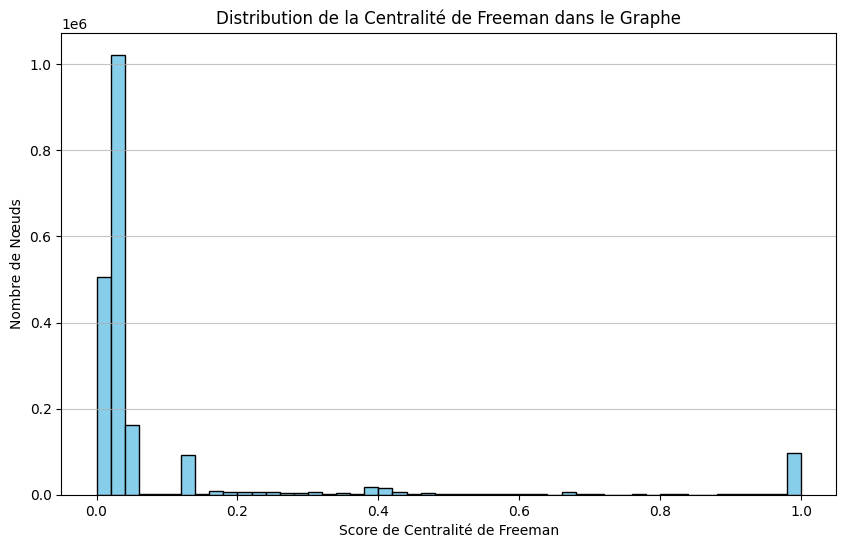

In [31]:
# Calcul de la centralité de Freeman pour un sous-graphe donné
def calculate_freeman(subgraph):
    n = subgraph.number_of_nodes()
    if n < 5:
        return 0.0, 0  # Pas défini pour les graphes avec moins de 2 nœuds

    degrees = dict(subgraph.degree())
    max_deg = max(degrees.values())
    sum_diff = sum(max_deg - deg for deg in degrees.values())
    
    # Calcul du score de Freeman
    freeman_score = sum_diff / ((n - 1) * (n - 2))
    return freeman_score, max_deg

# Analyser les structures détectées (communautés ou composantes)
for component in tqdm(nx.weakly_connected_components(G), desc="Analyse des composantes"):
    subgraph = G.subgraph(component)
    freeman_score, max_deg = calculate_freeman(subgraph)
    
    # Stocker les résultats dans le sous-graphe
    for node in subgraph.nodes():
        G.nodes[node]['freeman_centralization'] = freeman_score
        G.nodes[node]['max_degree_in_subgraph'] = max_deg

#Tracé des résultats sous forme d histogramme 
plt.figure(figsize=(10, 6))
plt.hist(
    [G.nodes[node]['freeman_centralization'] for node in G.nodes() if 'freeman_centralization' in G.nodes[node]],
    bins=50,
    color='skyblue',
    edgecolor='black'
)
plt.title("Distribution de la Centralité de Freeman dans le Graphe")
plt.xlabel("Score de Centralité de Freeman")
plt.ylabel("Nombre de Nœuds")
plt.grid(axis='y', alpha=0.75)
plt.show()
    

2016165
Comptage en cours...

🔹 Répartition des types de nœuds dans les paradis fiscaux :
   - entity: 380694
   - officer: 194355
   - address: 136959
   - intermediary: 11388

🔹 Répartition des types de nœuds dans les juridictions standard :
   - officer: 576838
   - entity: 433466
   - address: 265271
   - intermediary: 14205
   - Unknown: 2989


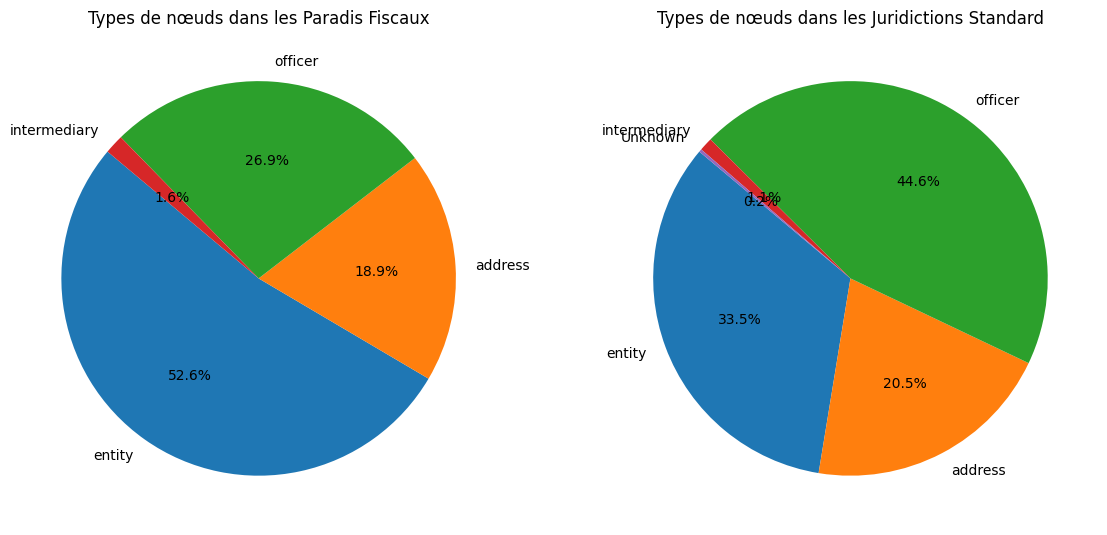

In [ ]:
# Mesure des proportion de types de noeuds dans les paradis fiscaux vs autres pays

# 1. CORRECTION ICI : On utilise directement Counter()
type_counts_tax_haven = Counter()
type_counts_non_tax_haven = Counter()

print(len(G.nodes()))

print("Comptage en cours...")

for node_id, attributes in G.nodes(data=True):
    # Récupération sécurisée des attributs
    node_type = attributes.get('type', 'Unknown')
    
    # Attention aux données : parfois c'est boolean (True), parfois string ("Yes")
    # On gère les deux cas pour être sûr
    is_tax_haven = attributes.get('Is_Tax_Haven')
    
    if is_tax_haven == "Yes" or is_tax_haven is True:
        # Ici la clé est 'node_type', on incrémente la valeur
        type_counts_tax_haven[node_type] += 1
    else:
        type_counts_non_tax_haven[node_type] += 1

# Affichage des résultats
print("\n🔹 Répartition des types de nœuds dans les paradis fiscaux :" )
# .most_common() est pratique pour trier automatiquement du plus fréquent au moins fréquent
for node_type, count in type_counts_tax_haven.most_common():
    print(f"   - {node_type}: {count}")

print("\n🔹 Répartition des types de nœuds dans les juridictions standard :" )
for node_type, count in type_counts_non_tax_haven.most_common():
    print(f"   - {node_type}: {count}")

# Plot des camemberts
labels_tax_haven = list(type_counts_tax_haven.keys())
sizes_tax_haven = list(type_counts_tax_haven.values())
labels_non_tax_haven = list(type_counts_non_tax_haven.keys())
sizes_non_tax_haven = list(type_counts_non_tax_haven.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
ax1.pie(sizes_tax_haven, labels=labels_tax_haven, autopct='%1.1f%%', startangle=140)
ax1.set_title("Types de nœuds dans les Paradis Fiscaux")
ax2.pie(sizes_non_tax_haven, labels=labels_non_tax_haven, autopct='%1.1f%%', startangle=140)
ax2.set_title("Types de nœuds dans les Juridictions Standard")
plt.show()  

In [ ]:
# 1. Calcul du seuil et filtrage
b_values = [data['Betweenness'] for node, data in G.nodes(data=True) if 'Betweenness' in data]
threshold = 0.00000000000000001

top_10_percent_nodes = [
    (node, data) 
    for node, data in G.nodes(data=True) 
    if data.get('Betweenness', 0) >= threshold
]

print(f"Analyse sur {len(top_10_percent_nodes)} nœuds à haute centralité.")

# 2. Initialisation de NOUVEAUX compteurs (spécifiques à cette analyse)
top10_counts_haven = Counter()
top10_counts_normal = Counter()

# 3. Boucle corrigée
for node, data in top_10_percent_nodes:
    # CORRECTION : On utilise 'data', pas 'attributes'
    node_type = data.get('type', 'Unknown')
    is_tax_haven = data.get('Is_Tax_Haven')

    if is_tax_haven == "Yes" or is_tax_haven is True:
        top10_counts_haven[node_type] += 1
    else:
        top10_counts_normal[node_type] += 1

# 4. Affichage console
print("\n🔹 [Top 10% Betweenness] Types dans les paradis fiscaux :" )
for t, c in top10_counts_haven.most_common():
    print(f"   - {t}: {c}")

print("\n🔹 [Top 10% Betweenness] Types dans les juridictions standard :" )
for t, c in top10_counts_normal.most_common():
    print(f"   - {t}: {c}")

# 5. Visualisation (Camemberts)
# On vérifie qu'on a des données pour éviter une erreur de plot vide
if len(top10_counts_haven) > 0 and len(top10_counts_normal) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    
    ax1.pie(top10_counts_haven.values(), labels=top10_counts_haven.keys(), autopct='%1.1f%%', startangle=140)
    ax1.set_title(f"Top 10% Centralité : Paradis Fiscaux\n(Total: {sum(top10_counts_haven.values())})")
    
    ax2.pie(top10_counts_normal.values(), labels=top10_counts_normal.keys(), autopct='%1.1f%%', startangle=140)
    ax2.set_title(f"Top 10% Centralité : Pays Standard\n(Total: {sum(top10_counts_normal.values())})")
    
    plt.show()
else:
    print("Pas assez de données pour afficher les graphiques.")

Analyse sur 0 nœuds à haute centralité.

🔹 [Top 10% Betweenness] Types dans les paradis fiscaux :

🔹 [Top 10% Betweenness] Types dans les juridictions standard :
Pas assez de données pour afficher les graphiques.


Analyse sur 67 nœuds à haute centralité.

🔹 [Top 10% Betweenness] Types dans les paradis fiscaux :
   - intermediary: 41
   - address: 11
   - officer: 2

🔹 [Top 10% Betweenness] Types dans les juridictions standard :
   - intermediary: 5
   - address: 4
   - officer: 4


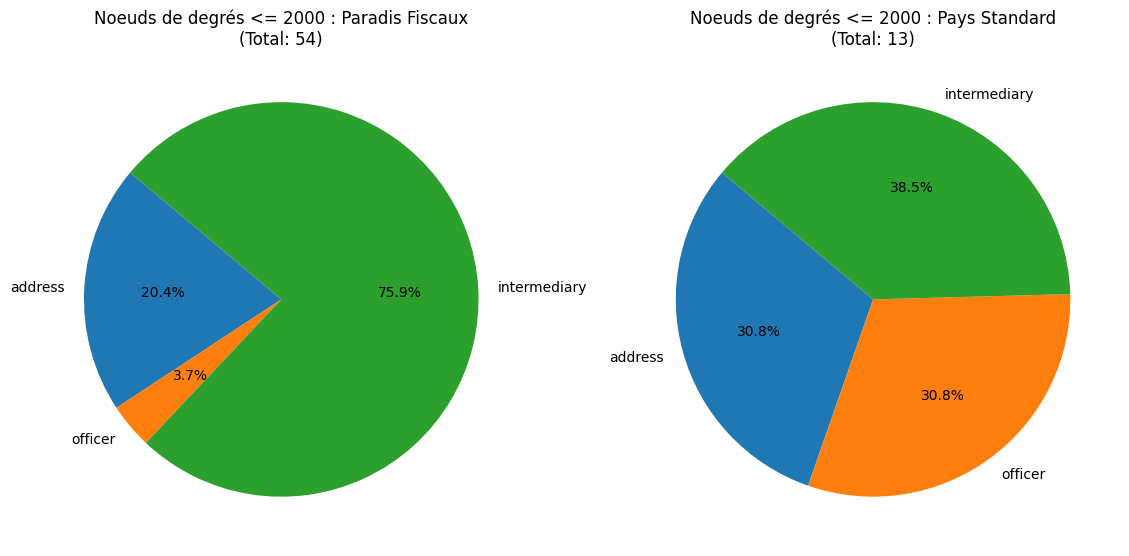

In [ ]:
# 1. Calcul du seuil et filtrage
b_values = [data['Degree'] for node, data in G.nodes(data=True) if 'Degree' in data]
threshold = 2000

top_10_percent_nodes = [
    (node, data) 
    for node, data in G.nodes(data=True) 
    if data.get('Degree', 0) >= threshold
]

print(f"Analyse sur {len(top_10_percent_nodes)} nœuds à haute centralité.")

# 2. Initialisation de NOUVEAUX compteurs (spécifiques à cette analyse)
top10_counts_haven = Counter()
top10_counts_normal = Counter()

# 3. Boucle corrigée
for node, data in top_10_percent_nodes:
    # CORRECTION : On utilise 'data', pas 'attributes'
    node_type = data.get('type', 'Unknown')
    is_tax_haven = data.get('Is_Tax_Haven')

    if is_tax_haven == "Yes" or is_tax_haven is True:
        top10_counts_haven[node_type] += 1
    else:
        top10_counts_normal[node_type] += 1

# 4. Affichage console
print("\n🔹 [Top 10% Betweenness] Types dans les paradis fiscaux :" )
for t, c in top10_counts_haven.most_common():
    print(f"   - {t}: {c}")

print("\n🔹 [Top 10% Betweenness] Types dans les juridictions standard :" )
for t, c in top10_counts_normal.most_common():
    print(f"   - {t}: {c}")

# 5. Visualisation (Camemberts)
# On vérifie qu'on a des données pour éviter une erreur de plot vide
if len(top10_counts_haven) > 0 and len(top10_counts_normal) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))
    
    ax1.pie(top10_counts_haven.values(), labels=top10_counts_haven.keys(), autopct='%1.1f%%', startangle=140)
    ax1.set_title(f"Noeuds de degrés <= {threshold} : Paradis Fiscaux\n(Total: {sum(top10_counts_haven.values())})")
    
    ax2.pie(top10_counts_normal.values(), labels=top10_counts_normal.keys(), autopct='%1.1f%%', startangle=140)
    ax2.set_title(f"Noeuds de degrés <= {threshold} : Pays Standard\n(Total: {sum(top10_counts_normal.values())})")
    
    plt.show()
else:
    print("Pas assez de données pour afficher les graphiques.")

Conversion du graphe en tableau pour analyse...
Calcul des proportions par seuil...


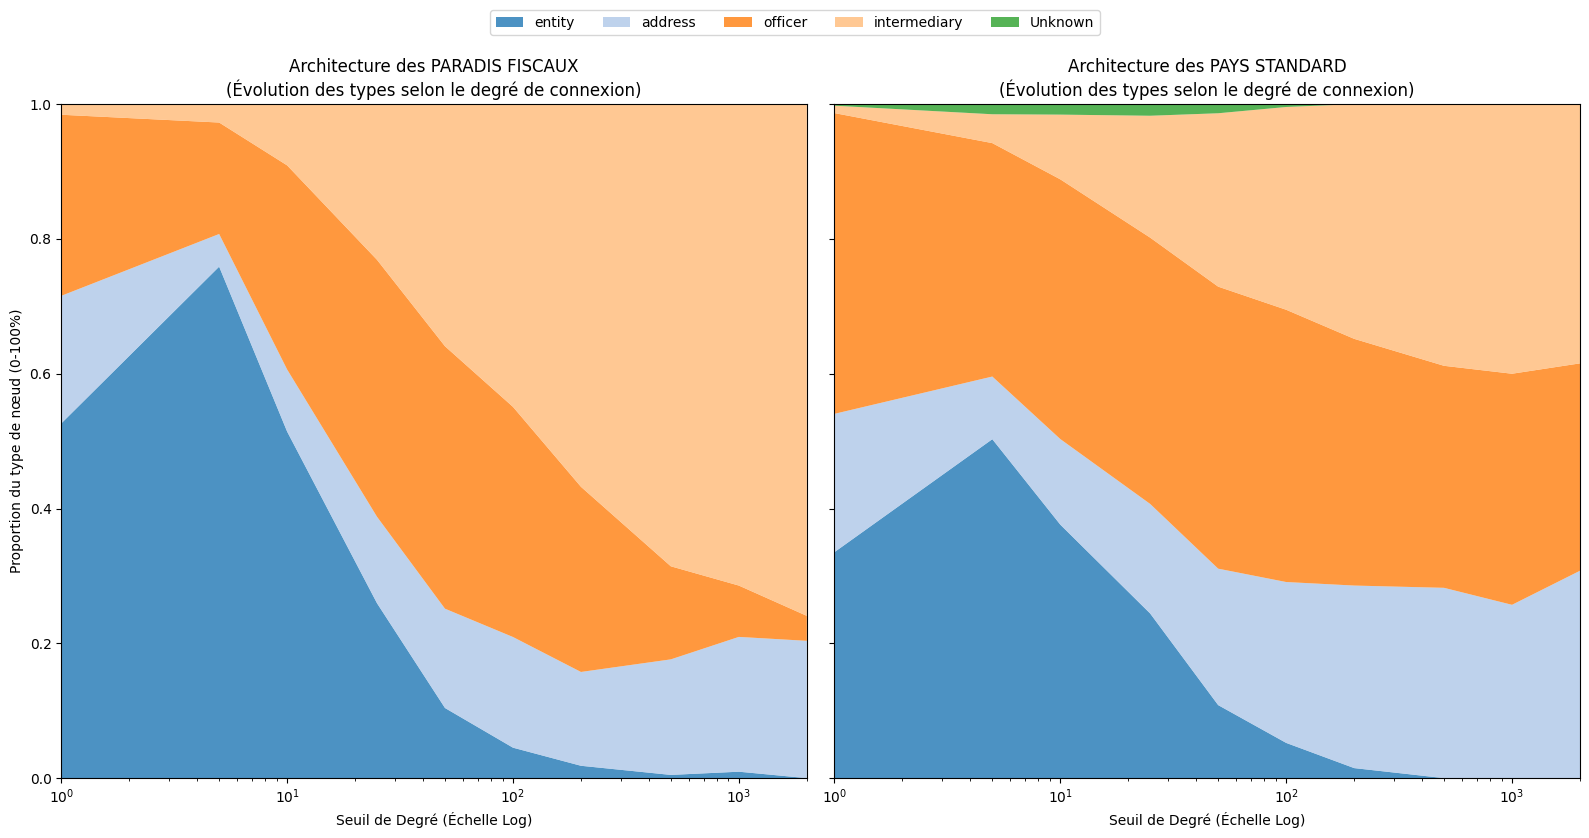

In [ ]:
# 1. Conversion rapide des données du Graphe en DataFrame Pandas
# C'est beaucoup plus rapide pour manipuler des millions de lignes
print("Conversion du graphe en tableau pour analyse...")
df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')

# Nettoyage et préparation
df['Degree'] = df['Degree'].fillna(0) # Sécurité
df['type'] = df['type'].fillna('Unknown')
# Harmonisation de la colonne 'Is_Tax_Haven' (gestion des True/False/"Yes"/"No")
df['Is_Tax_Haven'] = df['Is_Tax_Haven'].apply(lambda x: True if x == "Yes" or x is True else False)

# 2. Définition des seuils (l'axe X de ton graphique)
# On choisit une échelle logarithmique car le degré varie énormément
thresholds = [1, 5, 10, 25, 50, 100, 200, 500, 1000, 2000]

# Listes pour stocker les résultats
history_haven = []
history_normal = []

# On veut connaître tous les types possibles pour les couleurs (ex: Entity, Officer, Address...)
all_types = df['type'].unique()

print("Calcul des proportions par seuil...")

for t in thresholds:
    # FILTRAGE : On garde les nœuds qui ont au moins 't' connexions
    subset = df[df['Degree'] >= t]
    
    # --- A. Pour les Paradis Fiscaux ---
    subset_haven = subset[subset['Is_Tax_Haven'] == True]
    if len(subset_haven) > 0:
        # Calcule les pourcentages de chaque type
        counts = subset_haven['type'].value_counts(normalize=True)
        # On s'assure d'avoir tous les types (même si 0%) pour que le graphique ne bug pas
        counts = counts.reindex(all_types, fill_value=0) 
        history_haven.append(counts)
    else:
        history_haven.append(pd.Series(0, index=all_types)) # Cas vide

    # --- B. Pour les Pays "Normaux" ---
    subset_normal = subset[subset['Is_Tax_Haven'] == False]
    if len(subset_normal) > 0:
        counts = subset_normal['type'].value_counts(normalize=True)
        counts = counts.reindex(all_types, fill_value=0)
        history_normal.append(counts)
    else:
        history_normal.append(pd.Series(0, index=all_types))

# Transformation en DataFrame pour le plot
df_plot_haven = pd.DataFrame(history_haven, index=thresholds)
df_plot_normal = pd.DataFrame(history_normal, index=thresholds)

# 3. Création du Graphique (Double Stackplot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Couleurs consistante
colors = plt.cm.tab20.colors[:len(all_types)]

# --- Graphique GAUCHE : Paradis Fiscaux ---
ax1.stackplot(thresholds, df_plot_haven.T, labels=all_types, colors=colors, alpha=0.8)
ax1.set_title("Architecture des PARADIS FISCAUX\n(Évolution des types selon le degré de connexion)")
ax1.set_xlabel("Seuil de Degré (Échelle Log)")
ax1.set_ylabel("Proportion du type de nœud (0-100%)")
ax1.set_xscale('log') # Important pour voir les détails
ax1.set_xlim(left=1, right=max(thresholds))
ax1.margins(0, 0) # Enlève les marges blanches au bord

# --- Graphique DROITE : Pays Standard ---
ax2.stackplot(thresholds, df_plot_normal.T, labels=all_types, colors=colors, alpha=0.8)
ax2.set_title("Architecture des PAYS STANDARD\n(Évolution des types selon le degré de connexion)")
ax2.set_xlabel("Seuil de Degré (Échelle Log)")
ax2.set_xscale('log')
ax2.set_xlim(left=1, right=max(thresholds))
ax2.margins(0, 0)

# Légende unique
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(all_types))

plt.tight_layout()
plt.show()

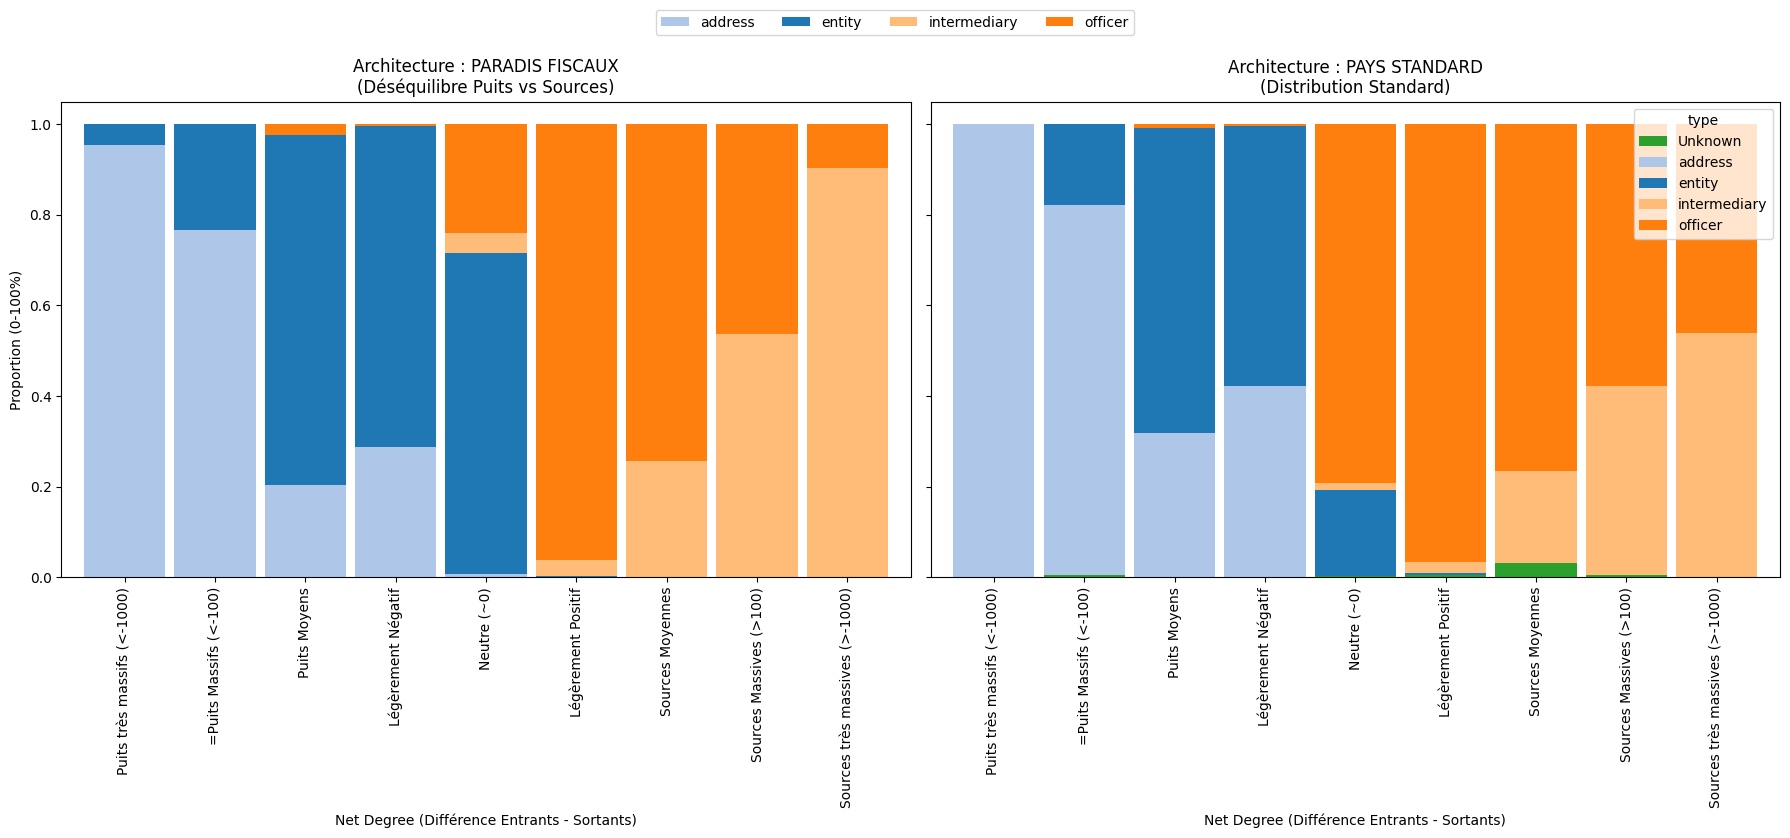

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Préparation des données (comme avant)
df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
df['Net_Degree'] = df['Net_Degree'].fillna(0)
df['type'] = df['type'].fillna('Unknown')
df['Is_Tax_Haven'] = df['Is_Tax_Haven'].apply(lambda x: True if x == "Yes" or x is True else False)

# 2. Création des INTERVALLES (Bins)
# C'est ici que la magie opère. On définit des tranches précises.
# On veut isoler les extrêmes négatifs, le zéro, et les extrêmes positifs.
bins = [-float('inf'),-1000, -100, -10, -1, 1, 10, 100, 1000,float('inf')]
labels_bins = ['Puits très massifs (<-1000)','=Puits Massifs (<-100)', 'Puits Moyens', 'Légèrement Négatif', 'Neutre (~0)', 'Légèrement Positif', 'Sources Moyennes', 'Sources Massives (>100)','Sources très massives (>-1000)']

# On catégorise chaque nœud dans une "boîte"
df['Category_Net'] = pd.cut(df['Net_Degree'], bins=bins, labels=labels_bins)

# 3. Fonction pour calculer les proportions par Bin
def get_proportions(df_subset):
    # On compte combien de types il y a dans chaque intervalle
    counts = df_subset.groupby(['Category_Net', 'type'], observed=False).size().unstack(fill_value=0)
    # On convertit en pourcentage (100% par barre)
    proportions = counts.div(counts.sum(axis=1), axis=0)
    return proportions

# Sépare les données
props_haven = get_proportions(df[df['Is_Tax_Haven'] == True])
props_normal = get_proportions(df[df['Is_Tax_Haven'] == False])

# 4. Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# Définition des couleurs unifiées
all_types = df['type'].unique()
colors = plt.cm.tab20.colors[:len(all_types)]
color_map = {t: c for t, c in zip(all_types, colors)}

# --- Graphique 1 : Paradis Fiscaux ---
props_haven.plot(kind='bar', stacked=True, ax=ax1, color=[color_map.get(x, '#333333') for x in props_haven.columns], width=0.9)
ax1.set_title("Architecture : PARADIS FISCAUX\n(Déséquilibre Puits vs Sources)")
ax1.set_ylabel("Proportion (0-100%)")
ax1.set_xlabel("Net Degree (Différence Entrants - Sortants)")
ax1.legend_.remove() # On enlève la légende ici pour ne pas surcharger

# --- Graphique 2 : Pays Standard ---
props_normal.plot(kind='bar', stacked=True, ax=ax2, color=[color_map.get(x, '#333333') for x in props_normal.columns], width=0.9)
ax2.set_title("Architecture : PAYS STANDARD\n(Distribution Standard)")
ax2.set_xlabel("Net Degree (Différence Entrants - Sortants)")

# Légende commune propre
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(all_types))

plt.tight_layout()
plt.show()


Classification des nœuds (Source / Puits / Transit)...
Role              Puits     Source    Transit
Is_Tax_Haven                                 
False         44.048937  38.751007  17.200057
True          43.574750  26.801503  29.623747


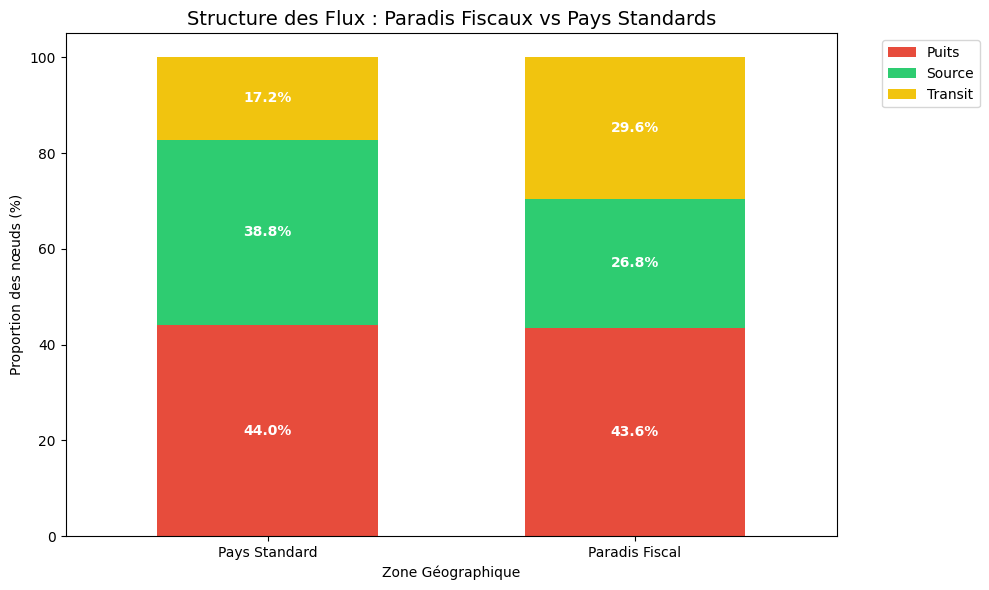

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

# 1. Calcul des rôles pour chaque nœud
# C'est très rapide, on regarde juste les voisins entrants et sortants
print("Classification des nœuds (Source / Puits / Transit)...")

roles = {}
for node in G.nodes():
    in_deg = G.in_degree(node)
    out_deg = G.out_degree(node)
    
    if in_deg == 0 and out_deg > 0:
        roles[node] = 'Source'
    elif in_deg > 0 and out_deg == 0:
        roles[node] = 'Puits'
    elif in_deg > 0 and out_deg > 0:
        roles[node] = 'Transit'
    else:
        roles[node] = 'Isolé'

# On ajoute l'info au DataFrame précédent
df['Role'] = df.index.map(roles)

# 2. Comparaison Paradis Fiscal vs Normal
# On groupe par statut fiscal et par rôle, puis on compte
comparison = df.groupby(['Is_Tax_Haven', 'Role']).size().unstack(fill_value=0)

# Conversion en pourcentage pour pouvoir comparer des pays de tailles différentes
comparison_pct = comparison.div(comparison.sum(axis=1), axis=0) * 100

print(comparison_pct)

# 3. Visualisation Simplifiée
fig, ax = plt.subplots(figsize=(10, 6))

# On définit des couleurs parlantes
colors = {
    'Source': '#2ecc71',      # Vert (Départ)
    'Transit': '#f1c40f', # Jaune (Circulation)
    'Puits': '#e74c3c', # Rouge (Stop)
    'Isolé': '#95a5a6'
}
# On aligne les couleurs avec l'ordre des colonnes
plot_colors = [colors.get(c, '#333333') for c in comparison_pct.columns]

comparison_pct.plot(kind='bar', stacked=True, ax=ax, color=plot_colors, width=0.6)

ax.set_title("Structure des Flux : Paradis Fiscaux vs Pays Standards", fontsize=14)
ax.set_ylabel("Proportion des nœuds (%)")
ax.set_xlabel("Zone Géographique")
ax.set_xticklabels(['Pays Standard', 'Paradis Fiscal'], rotation=0)

# Ajout des valeurs dans les barres pour la lisibilité
for n, x in enumerate([*comparison.index.values]):
    for (cn, y) in enumerate(comparison_pct.iloc[n]):
        if y > 5:  # On n'affiche que si > 5% pour ne pas surcharger
            plt.text(n, 
                     comparison_pct.iloc[n][:cn].sum() + y/2, 
                     f"{y:.1f}%", 
                     ha='center', va='center', color='white', fontweight='bold')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Nombre de racines (points de départ) trouvées : 694842
Le graphe contient des cycles (boucles de propriété) ! C'est un indicateur fort de fraude.
Analyse des cycles dans le graphe...
Nombre de cycles simples détectés : 17166
Longueurs des cycles détectés (exemples) : [2, 2, 2, 2, 2]
Calcul des profondeurs des montages (Layering)...


/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_50312/3321793379.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


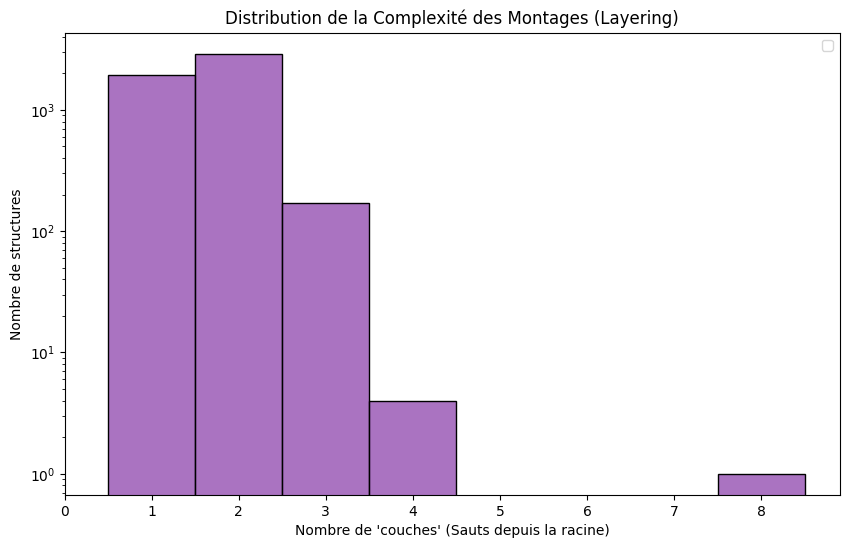


Profondeur maximale détectée : 8 couches.
Cela signifie qu'il faut traverser 8 sociétés pour trouver le bout de la chaîne.


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identification des Racines (Sources)
# Ce sont les points d'entrée du graphe (ex: Intermédiaires, ou les vrais bénéficiaires au sommet)
roots = [n for n, d in G.in_degree() if d == 0]

print(f"Nombre de racines (points de départ) trouvées : {len(roots)}")

# 2. Calcul de la profondeur maximale pour chaque racine
# Pour chaque racine, on regarde quel est le chemin le plus long qu'elle initie.
# Attention : C'est gourmand en calcul, on va utiliser une astuce (BFS)
max_depths = []

# On travaille sur les composantes pour aller plus vite, ou on itère si le graphe n'est pas trop gros
# Ici, vu que tu as mentionné des limites, on va faire un échantillonnage ou tout traiter si < 50k nœuds

# Note : Si le graphe a des cycles (A possède B qui possède A), la profondeur est infinie.
# On va détecter les cycles au passage.
has_cycles = False

try:
    # Si le graphe est un DAG (Directed Acyclic Graph), c'est très rapide
    longest_path = nx.dag_longest_path_length(G)
    print(f"La chaîne la plus longue du graphe fait {longest_path} sauts.")
except nx.NetworkXUnfeasible:
    print("Le graphe contient des cycles (boucles de propriété) ! C'est un indicateur fort de fraude.")
    has_cycles = True
    # Dans ce cas, on ne peut pas utiliser l'algo simple, on passe à l'étape suivante

#Mesure du nombre de cycles simples dans le graphe et leur taille
if has_cycles:
    print("Analyse des cycles dans le graphe...")
    simple_cycles = list(nx.simple_cycles(G))
    print(f"Nombre de cycles simples détectés : {len(simple_cycles)}")
    if simple_cycles:
        cycle_lengths = [len(cycle) for cycle in simple_cycles]
        print(f"Longueurs des cycles détectés (exemples) : {cycle_lengths[:5]}")


# Analyse statistique des profondeurs (Approximation par BFS depuis les racines)
path_lengths = []

print("Calcul des profondeurs des montages (Layering)...")
# Pour ne pas exploser ton CPU, on va analyser un sous-ensemble de racines si > 10000
import random
sample_roots = roots if len(roots) < 5000 else random.sample(roots, 5000)

for root in sample_roots:
    try:
        # Calcule les chemins les plus courts vers tous les descendants accessibles
        # On prend la valeur max de ces longueurs = la profondeur du montage sous cette racine
        lengths = nx.single_source_shortest_path_length(G, root)
        if lengths:
            max_depth = max(lengths.values())
            path_lengths.append(max_depth)
    except:
        pass

# 3. Visualisation : Histogramme des Profondeurs (Layering)
plt.figure(figsize=(10, 6))
sns.histplot(path_lengths, bins=range(0, max(path_lengths)+2), discrete=True, color='#8e44ad')

plt.title("Distribution de la Complexité des Montages (Layering)")
plt.xlabel("Nombre de 'couches' (Sauts depuis la racine)")
plt.ylabel("Nombre de structures")
plt.yscale('log')  # Pour mieux voir les détails
plt.xticks(range(0, max(path_lengths)+1))

# Zone "Suspecte"

plt.legend()

plt.show()

# 4. Afficher quelques exemples extrêmes
# Si on a trouvé des chaînes très longues, affichons qui est au sommet
if path_lengths:
    max_val = max(path_lengths)
    print(f"\nProfondeur maximale détectée : {max_val} couches.")
    print("Cela signifie qu'il faut traverser", max_val, "sociétés pour trouver le bout de la chaîne.")


In [ ]:
nx.write_gexf(G, "graph_tax_havens_enriched.gexf")

In [ ]:
print("nombre de nœuds final dans le graphe enrichi :", G.number_of_nodes())
print("nombre de relations final dans le graphe enrichi :", G.number_of_edges())

nombre de nœuds final dans le graphe enrichi : 2016165
nombre de relations final dans le graphe enrichi : 2897134


In [ ]:
# Liste des codes/juridictions pour les États-Unis
us_criteria = [
    "US", "US-DE", "Delaware", "United States", "USA"
]

# Fonction pour vérifier si un nœud est américain
def is_us_node(node_id):
    node = G.nodes[node_id]
    jurisdiction = node.get("jurisdiction", "")
    country_codes = node.get("country_codes", "")
    jurisdiction_desc = node.get("jurisdiction_description", "")

    return (
        jurisdiction in us_criteria or
        any(code in us_criteria for code in str(country_codes).split(",")) or
        any(crit in str(jurisdiction_desc) for crit in us_criteria)
    )

# Extraire les nœuds américains
us_nodes = [node for node in G.nodes() if is_us_node(node)]
print(f"Nombre d'entités américaines : {len(us_nodes)}")

Nombre d'entités américaines : 56512


In [ ]:
# --- Étape 1 : Trouver tous les nœuds accessibles depuis les entreprises américaines ---
us_nodes = [node for node in G.nodes() if is_us_node(node)]  # (utilisez la fonction is_us_node() définie précédemment)

# Ensemble des nœuds à conserver (initialement : les nœuds US + leurs voisins)
nodes_to_keep = set(us_nodes)

# Parcourir tous les nœuds US et ajouter leurs voisins (même indirects)
for us_node in us_nodes:
    # Utiliser BFS (Breadth-First Search) pour explorer tous les nœuds connectés
    for node in nx.descendants(G, us_node):  # Tous les nœuds accessibles depuis us_node
        nodes_to_keep.add(node)
    for node in nx.ancestors(G, us_node):    # Tous les nœuds qui mènent à us_node
        nodes_to_keep.add(node)


subgraph = G.subgraph(nodes_to_keep).copy()

print(f"Sous-graphe final : {subgraph.number_of_nodes()} nœuds, {subgraph.number_of_edges()} arêtes.")


In [ ]:
# ajouter betweenness centrality au sous graphe
def add_betweenness_centrality(G):
    betweenness = nx.betweenness_centrality(G, k = 400,normalized=False, weight=None)
    for node in tqdm(G.nodes()):
        G.nodes[node]['Betweenness'] = betweenness[node]

add_betweenness_centrality(subgraph)


100%|██████████| 92810/92810 [00:00<00:00, 4891966.65it/s]


In [ ]:
nx.write_gexf(subgraph, "graph_tax_havens_us.gexf")

Extraction des données du sous-graphe...
Calcul des proportions par seuil de Betweenness...


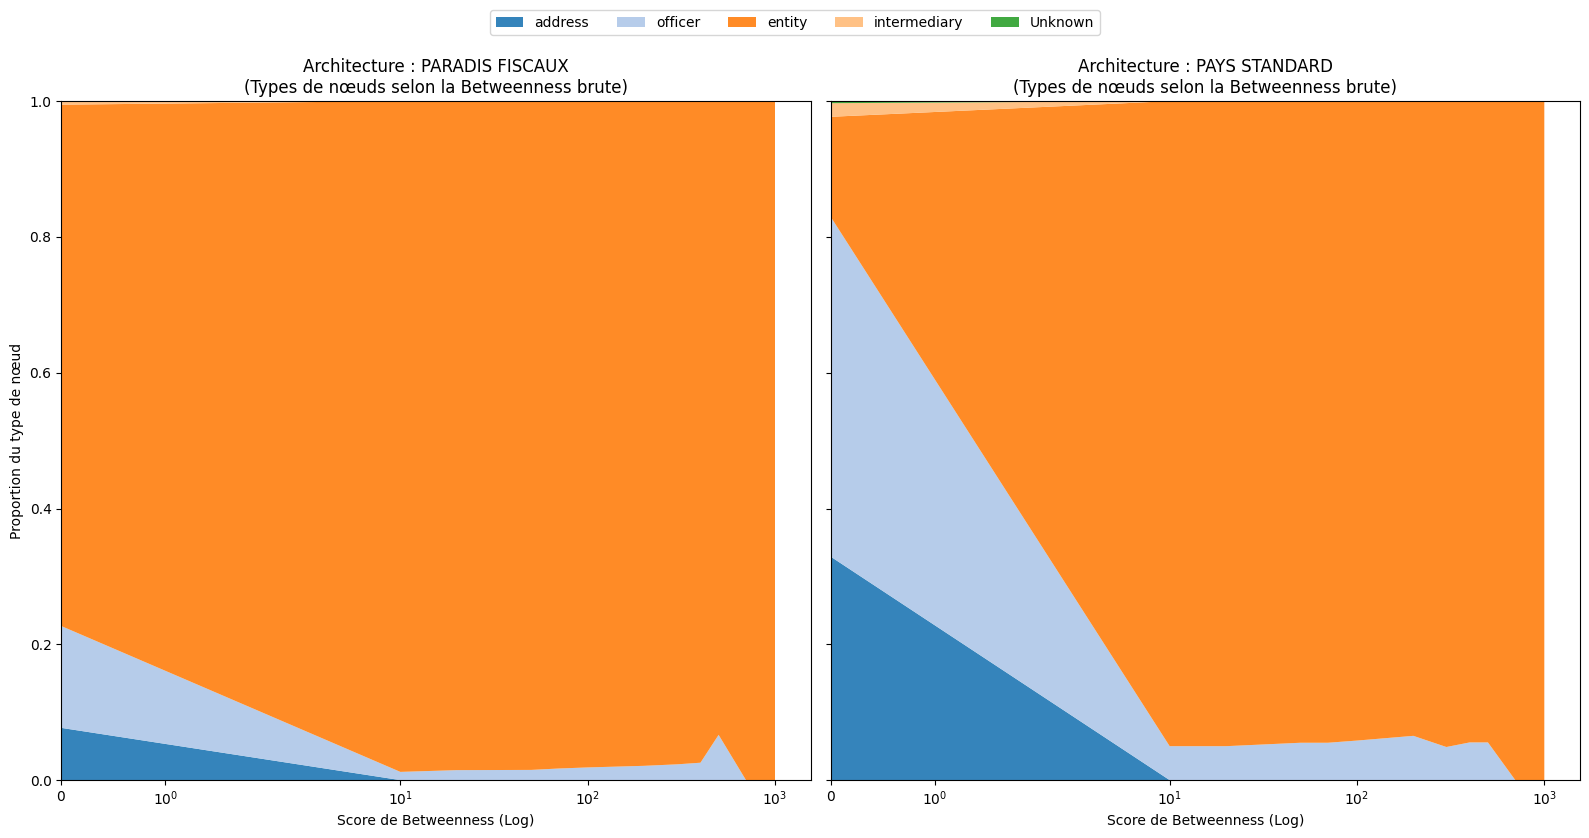

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Conversion du sous-graphe en DataFrame
# On suppose que ton graphe s'appelle 'subgraph' d'après ton message précédent
print("Extraction des données du sous-graphe...")
df = pd.DataFrame.from_dict(dict(subgraph.nodes(data=True)), orient='index')

# Nettoyage
df['Betweenness'] = df['Betweenness'].fillna(0)
df['type'] = df['type'].fillna('Unknown')
# Harmonisation Tax Haven
df['Is_Tax_Haven'] = df['Is_Tax_Haven'].apply(lambda x: True if x == "Yes" or x is True else False)

# 2. Définition des seuils (ADAPTÉ pour normalized=False)
# Comme ce n'est pas normalisé, les valeurs peuvent être grandes.
# On prend une échelle large pour voir la progression.
thresholds = [0, 10,20, 50,70, 100,200,300,400, 500,700, 1000]

history_haven = []
history_normal = []

# Récupération de tous les types uniques pour les couleurs
all_types = df['type'].unique()

print("Calcul des proportions par seuil de Betweenness...")

for t in thresholds:
    # FILTRAGE : On garde les nœuds avec un score >= t
    subset = df[df['Betweenness'] >= t]

    # --- A. Pour les Paradis Fiscaux ---
    subset_haven = subset[subset['Is_Tax_Haven'] == True]
    if len(subset_haven) > 0:
        counts = subset_haven['type'].value_counts(normalize=True)
        counts = counts.reindex(all_types, fill_value=0) 
        history_haven.append(counts)
    else:
        history_haven.append(pd.Series(0, index=all_types))

    # --- B. Pour les Pays "Normaux" ---
    subset_normal = subset[subset['Is_Tax_Haven'] == False]
    if len(subset_normal) > 0:
        counts = subset_normal['type'].value_counts(normalize=True)
        counts = counts.reindex(all_types, fill_value=0)
        history_normal.append(counts)
    else:
        history_normal.append(pd.Series(0, index=all_types))

# Transformation en DataFrame
df_plot_haven = pd.DataFrame(history_haven, index=thresholds)
df_plot_normal = pd.DataFrame(history_normal, index=thresholds)

# 3. Visualisation Stackplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
colors = plt.cm.tab20.colors[:len(all_types)]

# --- Graphique GAUCHE : Paradis Fiscaux ---
ax1.stackplot(thresholds, df_plot_haven.T, labels=all_types, colors=colors, alpha=0.9)
ax1.set_title("Architecture : PARADIS FISCAUX\n(Types de nœuds selon la Betweenness brute)")
ax1.set_xlabel("Score de Betweenness (Log)")
ax1.set_ylabel("Proportion du type de nœud")
ax1.set_xscale('symlog') # 'symlog' gère mieux le 0 que 'log'
ax1.set_xlim(left=0) 
ax1.margins(0, 0)

# --- Graphique DROITE : Pays Standard ---
ax2.stackplot(thresholds, df_plot_normal.T, labels=all_types, colors=colors, alpha=0.9)
ax2.set_title("Architecture : PAYS STANDARD\n(Types de nœuds selon la Betweenness brute)")
ax2.set_xlabel("Score de Betweenness (Log)")
ax2.set_xscale('symlog')
ax2.set_xlim(left=0) 
ax2.margins(0, 0)

# Légende
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(all_types))

plt.tight_layout()
plt.show()


In [10]:
## Détection de communautés avec l'algorithme de Louvain
import community as community_louvain
G_undirected = G.to_undirected()
print("Détection des communautés avec l'algorithme de Louvain...")
partition = community_louvain.best_partition(G_undirected)
# Ajout des labels de communauté aux nœuds
for node, comm_id in tqdm(partition.items()):
    G.nodes[node]['Louvain_Community'] = comm_id




Détection des communautés avec l'algorithme de Louvain...


100%|██████████| 2016165/2016165 [00:00<00:00, 2933005.41it/s]


In [11]:
print("taille du graphe :", G.number_of_nodes(), "nœuds,", G.number_of_edges(), "arêtes.")

taille du graphe : 2016165 nœuds, 2897134 arêtes.


nombre de communautés détectées : 34348
Taille des communautés détectées (exemples) :
 - Communauté 2086 : 144162 nœuds
 - Communauté 11553 : 85262 nœuds
 - Communauté 18094 : 82658 nœuds
 - Communauté 8 : 76670 nœuds
 - Communauté 11357 : 50031 nœuds
 - Communauté 23637 : 46465 nœuds
 - Communauté 11554 : 40432 nœuds
 - Communauté 0 : 37159 nœuds
 - Communauté 24264 : 36001 nœuds
 - Communauté 23538 : 35360 nœuds


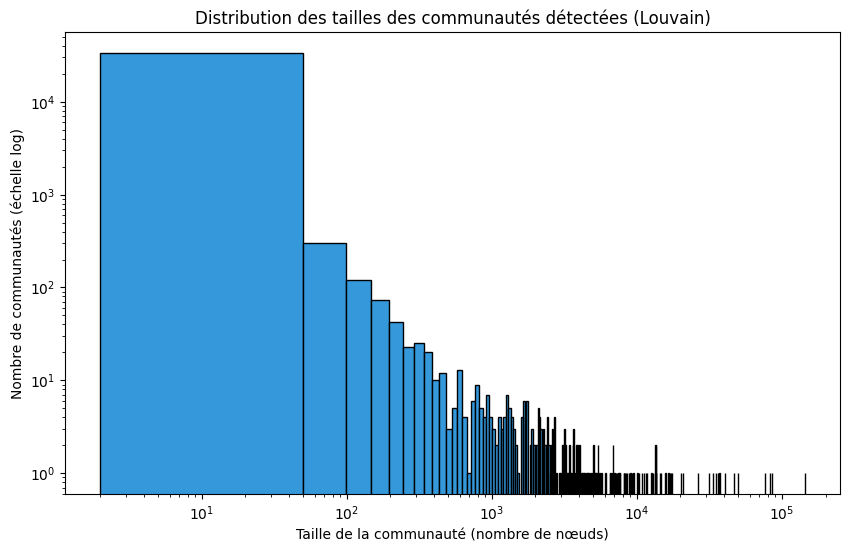

In [12]:
# Mesure le la taille des commnunautés détectées
from collections import Counter
community_sizes = Counter(partition.values())
print("nombre de communautés détectées :", len(community_sizes))
print("Taille des communautés détectées (exemples) :")
for comm_id, size in community_sizes.most_common(10):
    print(f" - Communauté {comm_id} : {size} nœuds")

#tracé de l'histogramme des tailles de communautés
plt.figure(figsize=(10, 6))
sizes = list(community_sizes.values())
plt.hist(sizes, bins=3000, color='#3498db', edgecolor='black')
plt.yscale('log')
plt.xscale('log')
plt.title("Distribution des tailles des communautés détectées (Louvain)")
plt.xlabel("Taille de la communauté (nombre de nœuds)")
plt.ylabel("Nombre de communautés (échelle log)")
plt.show()

100%|██████████| 2016165/2016165 [00:00<00:00, 2717467.70it/s]


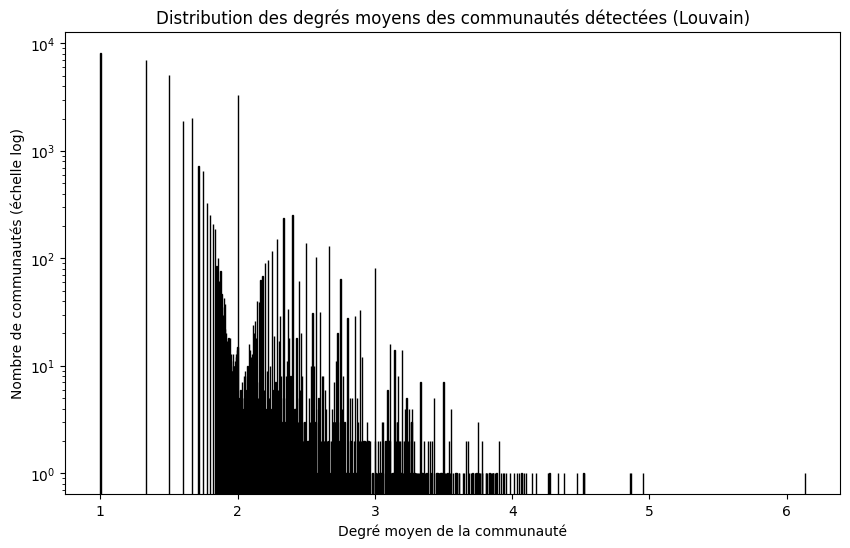

In [15]:
add_degree(G)
# Tracé de l'histogramme du degré moyen de chaque communauté
community_degrees = {}
for node, comm_id in partition.items():
    degree = G.nodes[node].get('Degree', 0)
    if comm_id not in community_degrees:
        community_degrees[comm_id] = []
    community_degrees[comm_id].append(degree)

avg_community_degrees = {comm_id: np.mean(degrees) for comm_id, degrees in community_degrees.items()}
plt.figure(figsize=(10, 6))
plt.hist(list(avg_community_degrees.values()), bins=3000, color='#e67e22', edgecolor='black')
plt.yscale('log')           
plt.title("Distribution des degrés moyens des communautés détectées (Louvain)") 
plt.xlabel("Degré moyen de la communauté")
plt.ylabel("Nombre de communautés (échelle log)")
plt.show()






In [16]:
# On récupère la communauté la plus connectée (au sens du degré moyen)

most_connected_community = max(avg_community_degrees, key=avg_community_degrees.get)
print(f"La communauté la plus connectée est la n° {most_connected_community} avec un degré moyen de {avg_community_degrees[most_connected_community]:.2f}.")

G_plus_connecté = G_undirected.subgraph([n for n, d in G.nodes(data=True) if d.get('Louvain_Community') == most_connected_community])
print("Taille du sous-graphe de la communauté la plus connectée :", G_plus_connecté.number_of_nodes(), "nœuds,", G_plus_connecté.number_of_edges(), "arêtes.")  

nx.write_gexf(G_plus_connecté, "graph_tax_havens_most_connected_community.gexf")

La communauté la plus connectée est la n° 1486 avec un degré moyen de 6.13.
Taille du sous-graphe de la communauté la plus connectée : 983 nœuds, 2978 arêtes.


In [18]:
# On récupère la plus grande communauté (au sens du nombre de nœuds)
largest_community = max(community_sizes, key=community_sizes.get)
print(f"La plus grande communauté est la n° {largest_community} avec {community_sizes[largest_community]} nœuds.")
G_plus_grande = G_undirected.subgraph([n for n, d in G.nodes(data=True) if d.get('Louvain_Community') == largest_community])
print("Taille du sous-graphe de la plus grande communauté :", G_plus_grande.number_of_nodes(), "nœuds,", G_plus_grande.number_of_edges(), "arêtes.")    
add_betweenness_centrality(G_plus_grande)
nx.write_gexf(G_plus_grande, "graph_tax_havens_largest_community.gexf")

La plus grande communauté est la n° 2065 avec 138398 nœuds.
Taille du sous-graphe de la plus grande communauté : 138398 nœuds, 261696 arêtes.


100%|██████████| 138398/138398 [00:00<00:00, 1303417.02it/s]


In [41]:
# On aetudie 10 composantes connexes les plus grandes
import random
G_quelques_composantes = nx.DiGraph()
connected_components = list(nx.weakly_connected_components(G))

connected_components.sort(key=len, reverse=True)
sampled_components = connected_components[8:9]
for i, component in tqdm(enumerate(sampled_components)):
    subgraph = G.subgraph(component).copy()
    print(f"Composante connexe {i+1} : {subgraph.number_of_nodes()} nœuds, {subgraph.number_of_edges()} arêtes.")
    G_quelques_composantes = nx.compose(G_quelques_composantes, subgraph)

nx.write_gexf(G_quelques_composantes, "graph_tax_havens_sampled_components.gexf")


    



1it [00:00, 13.89it/s]


Composante connexe 1 : 7566 nœuds, 11491 arêtes.


Nombre de composantes connexes détectées : 33068


100%|██████████| 2016165/2016165 [00:00<00:00, 7113973.64it/s]
/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_7279/1944935544.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([countries_per_component, countries_per_community], labels=['Composantes Connexes', 'Communautés Louvain'])


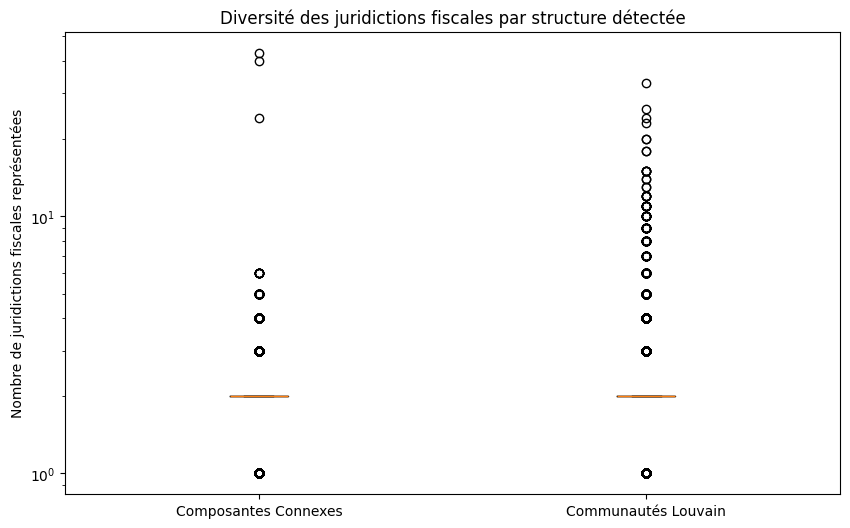

In [29]:
# Quelques analyses sur les communautés détectées

Components = list(nx.weakly_connected_components(G))
print("Nombre de composantes connexes détectées :", len(Components))
# Pour chaque composante connexe, on compte le nombre de juridictions fiscales représentées
countries_per_component = []
for component in tqdm(Components):
    subgraph = G.subgraph(component)
    countries_compo = set()
    for node in subgraph.nodes():
        jurisdiction = G.nodes[node].get('jurisdiction', 'Unknown')
        countries_compo.add(jurisdiction)
    countries_per_component.append(len(countries_compo))




# CRÉATION DES GRAPHES DES COMMUNAUTÉS PAR Louvain

Communities = {}
for node, comm_id in tqdm(partition.items()):
    if comm_id not in Communities:
        Communities[comm_id] = []
    Communities[comm_id].append(node)
countries_per_community = []
for comm_id, nodes in Communities.items():
    subgraph = G.subgraph(nodes)
    countries_comu = set()
    for node in subgraph.nodes():
        jurisdiction = G.nodes[node].get('jurisdiction', 'Unknown')
        countries_comu.add(jurisdiction)
    countries_per_community.append(len(countries_comu))


# On trace sous forme de boite à moustaches
plt.figure(figsize=(10, 6))
plt.boxplot([countries_per_component, countries_per_community], labels=['Composantes Connexes', 'Communautés Louvain'])
plt.ylabel("Nombre de juridictions fiscales représentées")
plt.yscale('log')
plt.title("Diversité des juridictions fiscales par structure détectée")
plt.show()


    


Nombre de composantes connexes détectées : 33068


Traitement composantes connexes: 100%|██████████| 33068/33068 [00:01<00:00, 20026.24it/s]



--- Statistiques pour les Composantes Connexes ---
Minimum : 0
Maximum : 210
Moyenne : 1.28
Médiane : 1.0
Nombre de valeurs uniques : 22
Échantillon (premières 10 valeurs) : [210, 1, 1, 1, 3, 2, 1, 1, 1, 1]


Traitement communautés Louvain: 100%|██████████| 34348/34348 [00:01<00:00, 26622.20it/s]


--- Statistiques pour les Communautés Louvain ---
Minimum : 0
Maximum : 184
Moyenne : 1.64
Médiane : 1.0
Nombre de valeurs uniques : 101
Échantillon (premières 10 valeurs) : [137, 1, 64, 131, 87, 1, 110, 34, 161, 78]


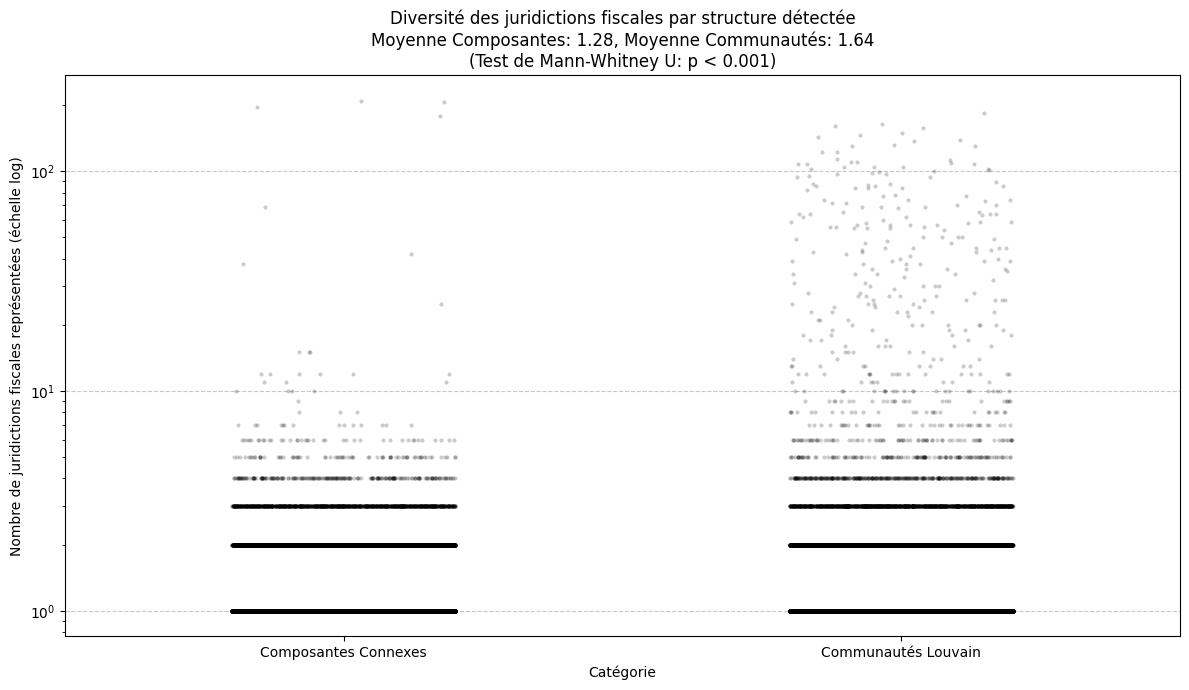

In [79]:
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import numpy as np # Pour les statistiques
import seaborn as sns
from scipy import stats

# --- Analyses sur les Composantes Connexes ---
Components = list(nx.weakly_connected_components(G))
print("Nombre de composantes connexes détectées :", len(Components))

countries_per_component = []
for component in tqdm(Components, desc="Traitement composantes connexes"):
    # On peut itérer directement sur les noeuds de la composante
    # sans générer de subgraph (c'est plus rapide)
    countries_compo = set()
    
    for node in component:
        raw_jurisdiction = G.nodes[node].get('country_codes', 'Unknown')
        
        # 1. Gestion des valeurs manquantes (None ou NaN)
        if raw_jurisdiction is None or (isinstance(raw_jurisdiction, float) and np.isnan(raw_jurisdiction)):
            continue
            
        # 2. Séparation des codes multiples (ex: "USA;FRA")
        jurisdictions_list = str(raw_jurisdiction).split(';')
        
        # 3. Ajout dans le set (qui dédoublonne automatiquement)
        for code in jurisdictions_list:
            clean_code = code.strip() # Enlève les espaces
            if clean_code and clean_code != 'Unknown': # On évite d'ajouter 'Unknown' ou vide si on veut compter les VRAIS pays
                countries_compo.add(clean_code)
                
    countries_per_component.append(len(countries_compo))

print("\n--- Statistiques pour les Composantes Connexes ---")
if countries_per_component:
    print(f"Minimum : {np.min(countries_per_component)}")
    print(f"Maximum : {np.max(countries_per_component)}")
    print(f"Moyenne : {np.mean(countries_per_component):.2f}")
    print(f"Médiane : {np.median(countries_per_component)}")
    print(f"Nombre de valeurs uniques : {len(set(countries_per_component))}")
    # Affiche un échantillon des premières valeurs
    print(f"Échantillon (premières 10 valeurs) : {countries_per_component[:10]}")
else:
    print("La liste countries_per_component est vide.")


# --- Analyses sur les Communautés Louvain ---
Communities = {}
for node, comm_id in tqdm(partition.items(), desc="Regroupement par communautés"):
    if comm_id not in Communities:
        Communities[comm_id] = []
    Communities[comm_id].append(node)

countries_per_community = []
for comm_id, nodes in tqdm(Communities.items(), desc="Traitement communautés Louvain"):
    # Pas besoin de créer forcément un subgraph si c'est juste pour lire les attributs des nodes
    # Mais on garde la logique pour la clarté
    # subgraph = G.subgraph(nodes) 
    
    countries_comu = set() # Le SET empêche automatiquement les doublons
    
    for node in nodes: # On peut itérer directement sur la liste de nodes
        raw_jurisdiction = G.nodes[node].get('country_codes', 'Unknown')
        
        # 1. Gestion des NaN / None
        if raw_jurisdiction is None or (isinstance(raw_jurisdiction, float) and np.isnan(raw_jurisdiction)):
            continue # On ignore ou on peut ajouter 'Unknown'
            
        # 2. Conversion en string et séparation des codes multiples (ex: "USA;FRA")
        # On suppose que le séparateur est ';' (standard OpenCorporates/ICIJ)
        jurisdictions_list = str(raw_jurisdiction).split(';')
        
        # 3. Ajout propre dans le set
        for code in jurisdictions_list:
            clean_code = code.strip() # Enlève les espaces éventuels
            if clean_code: # Vérifie que ce n'est pas une string vide
                countries_comu.add(clean_code)
    
    # Le len() du set nous donne le nombre de pays UNIQUES
    countries_per_community.append(len(countries_comu))

print("\n--- Statistiques pour les Communautés Louvain ---")
if countries_per_community:
    print(f"Minimum : {np.min(countries_per_community)}")
    print(f"Maximum : {np.max(countries_per_community)}")
    print(f"Moyenne : {np.mean(countries_per_community):.2f}")
    print(f"Médiane : {np.median(countries_per_community)}")
    print(f"Nombre de valeurs uniques : {len(set(countries_per_community))}")
    # Affiche un échantillon des premières valeurs
    print(f"Échantillon (premières 10 valeurs) : {countries_per_community[:10]}")
else:
    print("La liste countries_per_community est vide.")


mean_components = np.mean(countries_per_component)
mean_communities = np.mean(countries_per_community)

# --- Préparation des données pour Seaborn ---
df_plot = pd.DataFrame({
    'Nombre de juridictions fiscales': countries_per_component + countries_per_community,
    'Catégorie': ['Composantes Connexes'] * len(countries_per_component) + ['Communautés Louvain'] * len(countries_per_community)
})

# --- Calcul du test statistique de Mann-Whitney U ---
stat, p_value = stats.mannwhitneyu(countries_per_component, countries_per_community, alternative='two-sided')

# --- Affichage du graphique ---
plt.figure(figsize=(12, 7))
''''
# 1. Violinplot pour la densité de la distribution
sns.violinplot(
    x='Catégorie',
    y='Nombre de juridictions fiscales',
    data=df_plot,
    inner=None,
    palette='Pastel1',
    ax=plt.gca()
)
'''
# 2. Stripplot pour les points individuels avec jitter
sns.stripplot(
    x='Catégorie',
    y='Nombre de juridictions fiscales',
    data=df_plot,
    color='black',
    alpha=0.2,
    size=3,
    jitter=0.2,
    ax=plt.gca()
)


plt.ylabel("Nombre de juridictions fiscales représentées (échelle log)")
plt.yscale('log')
# --- Intégration des moyennes et de la p-value dans le titre ---
if p_value < 0.001:
    p_value_str = "p < 0.001"
elif p_value < 0.05:
    p_value_str = f"p = {p_value:.3f} (< 0.05)"
else:
    p_value_str = f"p = {p_value:.3f} (> 0.05)"

title_text = (f"Diversité des juridictions fiscales par structure détectée\n"
              f"Moyenne Composantes: {mean_components:.2f}, Moyenne Communautés: {mean_communities:.2f}\n"
              f"(Test de Mann-Whitney U: {p_value_str})")

plt.title(title_text)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [33]:
import random

# Affiche les attributs d'un nœud aléatoire
if G.number_of_nodes() > 0:
    sample_node = random.choice(list(G.nodes()))
    print(f"Attributs pour un nœud échantillon ({sample_node}) :")
    for attr, value in G.nodes[sample_node].items():
        print(f"  - {attr}: {value}")
else:
    print("Le graphe est vide.")

# Ou pour vérifier spécifiquement 'country_code'
nodes_with_country_code = [n for n in G.nodes() if 'country_code' in G.nodes[n]]
print(f"\nNombre de nœuds avec 'country_code': {len(nodes_with_country_code)} sur {G.number_of_nodes()}")


Attributs pour un nœud échantillon (56013736) :
  - type: officer
  - name: GOLDON LIMITED
  - country_codes: SYC
  - countries: Seychelles
  - Is_Tax_Haven: No
  - Degree: 2
  - Net_Degree: 2
  - Louvain_Community: 24304

Nombre de nœuds avec 'country_code': 0 sur 2016165


In [36]:
# Création de la plus grande communauté de Louvain 
largest_community = max(community_sizes, key=community_sizes.get)
print(f"La plus grande communauté est la n° {largest_community} avec {community_sizes[largest_community]} nœuds.")
G_largest_community = G_undirected.subgraph([n for n, d in G.nodes(data=True) if d.get('Louvain_Community') == largest_community])
print("Taille du sous-graphe de la plus grande communauté :", G_largest_community.number_of_nodes(), "nœuds,", G_largest_community.number_of_edges(), "arêtes.")    

nx.write_gexf(G_largest_community, "graph_tax_havens_largest_community.gexf")

La plus grande communauté est la n° 2086 avec 144162 nœuds.
Taille du sous-graphe de la plus grande communauté : 144162 nœuds, 272851 arêtes.


In [62]:
#On etudie les composantes de Louvain dans l ordre decroissant en taille 

import random
sorted_communities = sorted(Communities.items(), key=lambda item: len(item[1]), reverse=True)   
G_louvain_communities = nx.DiGraph()
for i, (comm_id, nodes) in tqdm(enumerate(sorted_communities), desc="Traitement des communautés Louvain"):
    if i <= 330:
        continue  
    if i >= 360:  # Limite à 10 communautés pour éviter un graphe trop grand
        break
    subgraph = G.subgraph(nodes).copy()
    print(f"Communauté Louvain {comm_id} : {subgraph.number_of_nodes()} nœuds, {subgraph.number_of_edges()} arêtes.")
    G_louvain_communities = nx.compose(G_louvain_communities, subgraph) 

print("\n--- Inspection des attributs de G_louvain_communities après composition ---")

if G_louvain_communities.number_of_nodes() == 0:
    print("Le graphe G_louvain_communities est vide ou n'a pas de nœuds après la composition.")
else:
    sample_nodes_louvain = list(G_louvain_communities.nodes())[:5]

    for i, node_id in enumerate(sample_nodes_louvain):
        print(f"\nAttributs du nœud {node_id} dans G_louvain_communities (échantillon {i+1}):")
        node_attributes = G_louvain_communities.nodes[node_id]
        if node_attributes:
            for attr_name, attr_value in node_attributes.items():
                print(f"  - {attr_name}: {attr_value} (type: {type(attr_value)})") # Ajout du type
        else:
            print(f"  Ce nœud {node_id} n'a aucun attribut dans G_louvain_communities.")

    found_country_codes_louvain = False
    for node_id in sample_nodes_louvain:
        if 'country_codes' in G_louvain_communities.nodes[node_id]:
            val = G_louvain_communities.nodes[node_id]['country_codes']
            print(f"Nœud {node_id} dans G_louvain_communities a 'country_codes': {val} (type: {type(val)})")
            found_country_codes_louvain = True
    if not found_country_codes_louvain and sample_nodes_louvain:
        print("ATTENTION : L'attribut 'country_codes' n'a pas été trouvé dans l'échantillon de nœuds de G_louvain_communities.")
    elif not sample_nodes_louvain:
        print("Aucun nœud à inspecter dans G_louvain_communities.")

# --- Ton code original pour l'exportation ---
nx.write_gexf(G_louvain_communities, "graph_tax_havens_louvain_communities.gexf")
print("\nLe graphe G_louvain_communities a été exporté en GEXF.")


Traitement des communautés Louvain: 342it [00:00, 3271.70it/s]

Communauté Louvain 1971 : 335 nœuds, 334 arêtes.
Communauté Louvain 7819 : 334 nœuds, 336 arêtes.
Communauté Louvain 11644 : 330 nœuds, 446 arêtes.
Communauté Louvain 9516 : 329 nœuds, 355 arêtes.
Communauté Louvain 1552 : 326 nœuds, 325 arêtes.
Communauté Louvain 23555 : 322 nœuds, 321 arêtes.
Communauté Louvain 6000 : 320 nœuds, 547 arêtes.
Communauté Louvain 23616 : 320 nœuds, 319 arêtes.
Communauté Louvain 79 : 319 nœuds, 353 arêtes.
Communauté Louvain 11022 : 319 nœuds, 323 arêtes.
Communauté Louvain 11054 : 319 nœuds, 318 arêtes.
Communauté Louvain 9023 : 314 nœuds, 313 arêtes.
Communauté Louvain 23578 : 313 nœuds, 312 arêtes.
Communauté Louvain 1003 : 312 nœuds, 334 arêtes.
Communauté Louvain 23600 : 311 nœuds, 310 arêtes.
Communauté Louvain 844 : 309 nœuds, 360 arêtes.
Communauté Louvain 15 : 305 nœuds, 318 arêtes.
Communauté Louvain 7200 : 305 nœuds, 304 arêtes.
Communauté Louvain 31840 : 303 nœuds, 466 arêtes.
Communauté Louvain 11650 : 300 nœuds, 395 arêtes.
Communauté Louva

Traitement des communautés Louvain: 360it [00:00, 1013.72it/s]

Communauté Louvain 6433 : 295 nœuds, 294 arêtes.
Communauté Louvain 23607 : 295 nœuds, 294 arêtes.
Communauté Louvain 11409 : 294 nœuds, 335 arêtes.
Communauté Louvain 2208 : 289 nœuds, 293 arêtes.
Communauté Louvain 11021 : 288 nœuds, 287 arêtes.
Communauté Louvain 11673 : 287 nœuds, 301 arêtes.
Communauté Louvain 8536 : 284 nœuds, 283 arêtes.

--- Inspection des attributs de G_louvain_communities après composition ---

Attributs du nœud 12005674 dans G_louvain_communities (échantillon 1):
  - type: officer (type: <class 'str'>)
  - name: THE BEARER (type: <class 'str'>)
  - country_codes: nan (type: <class 'float'>)
  - countries: nan (type: <class 'float'>)
  - Is_Tax_Haven: No (type: <class 'str'>)
  - Degree: 1 (type: <class 'int'>)
  - Net_Degree: 1 (type: <class 'int'>)
  - Louvain_Community: 1971 (type: <class 'int'>)

Attributs du nœud 12030235 dans G_louvain_communities (échantillon 2):
  - type: officer (type: <class 'str'>)
  - name: THE BEARER (type: <class 'str'>)
  - cou


Le graphe G_louvain_communities a été exporté en GEXF.


Communauté 0 : 37159 nœuds, 11792 nœuds de degré 1 (31.73%)
Communauté 1 : 7 nœuds, 2 nœuds de degré 1 (28.57%)
Communauté 2 : 3111 nœuds, 999 nœuds de degré 1 (32.11%)
Communauté 3 : 33431 nœuds, 10911 nœuds de degré 1 (32.64%)
Communauté 4 : 11567 nœuds, 6023 nœuds de degré 1 (52.07%)
Communauté 5 : 68 nœuds, 51 nœuds de degré 1 (75.00%)
Communauté 6 : 11741 nœuds, 4461 nœuds de degré 1 (38.00%)
Communauté 7 : 969 nœuds, 429 nœuds de degré 1 (44.27%)
Communauté 8 : 76670 nœuds, 33667 nœuds de degré 1 (43.91%)
Communauté 9 : 8885 nœuds, 2743 nœuds de degré 1 (30.87%)
Communauté 10 : 2311 nœuds, 753 nœuds de degré 1 (32.58%)
Communauté 11 : 2097 nœuds, 1276 nœuds de degré 1 (60.85%)
Communauté 12 : 3 nœuds, 2 nœuds de degré 1 (66.67%)
Communauté 13 : 248 nœuds, 75 nœuds de degré 1 (30.24%)
Communauté 14 : 1998 nœuds, 744 nœuds de degré 1 (37.24%)
Communauté 15 : 305 nœuds, 228 nœuds de degré 1 (74.75%)
Communauté 16 : 15749 nœuds, 7780 nœuds de degré 1 (49.40%)
Communauté 17 : 1750 nœu

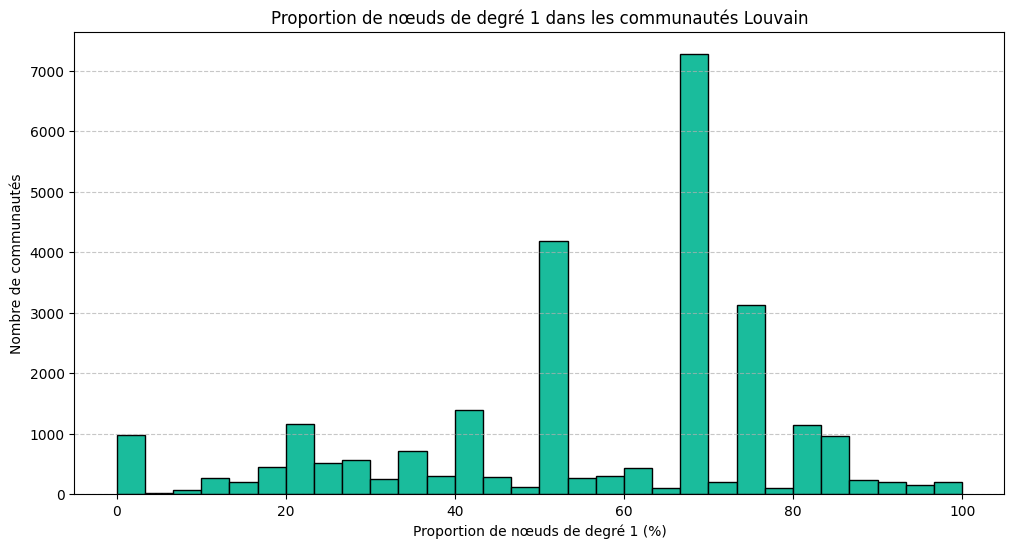

Communauté 0 : 37159 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 1 : 7 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 2 : 3111 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 3 : 33431 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 4 : 11567 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 5 : 68 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 6 : 11741 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 7 : 969 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 8 : 76670 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 9 : 8885 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 10 : 2311 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 11 : 2097 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 12 : 3 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 13 : 248 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 14 : 1998 nœuds, 0 nœuds pleinement connectés (0.00%)
Communauté 15 : 305 nœuds, 0 nœuds plein

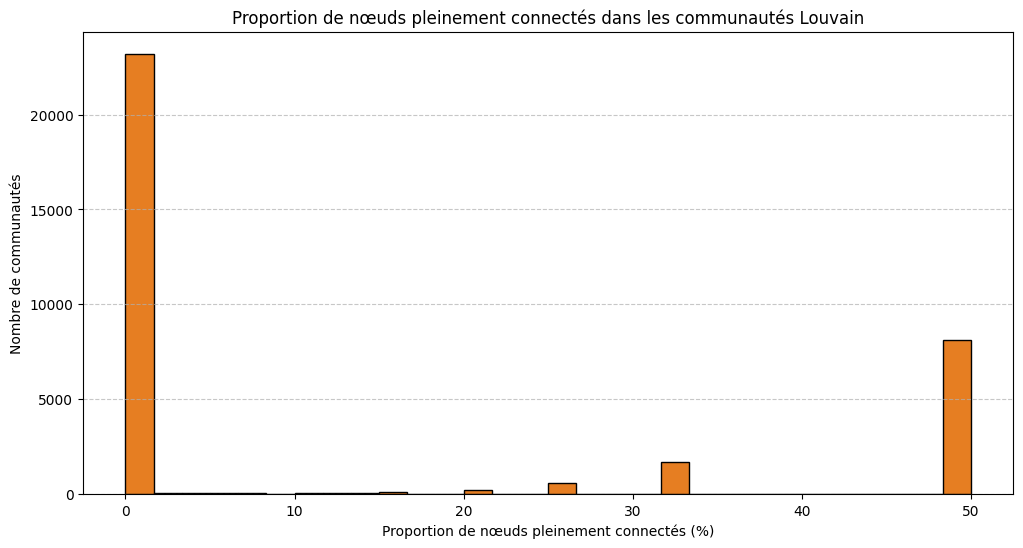

Pourcentage de communautés avec au moins un nœud pleinement connecté : 32.81%


In [ ]:
# Mesure des degrés des noeuds de chaque sous-graphe Louvain
# On veut connaitre la proportion de noeuds de degré 1 dans chaque sous-graphe
proportion_degree = []
for comm_id, nodes in Communities.items():
    if len(nodes) < 3:
        continue  # On ignore les petites communautés pour la statistique
    subgraph = G.subgraph(nodes)
    degrees = dict(subgraph.degree())
    total_nodes = len(degrees)
    degree_one_nodes = sum(1 for deg in degrees.values() if deg == 1)
    proportion_degree_one = (degree_one_nodes / total_nodes) * 100 if total_nodes > 0 else 0
    print(f"Communauté {comm_id} : {total_nodes} nœuds, {degree_one_nodes} nœuds de degré 1 ({proportion_degree_one:.2f}%)")
    proportion_degree.append(proportion_degree_one)

#Visualisation des proportions de nœuds de degré 1 par communauté Louvain
plt.figure(figsize=(12, 6))
plt.hist(proportion_degree, bins=30, color='#1abc9c', edgecolor='black')
plt.title("Proportion de nœuds de degré 1 dans les communautés Louvain")
plt.xlabel("Proportion de nœuds de degré 1 (%)")
plt.ylabel("Nombre de communautés")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



#On veut savoir si un noeud est connecté à tous les noeuds de sa communauté
fully_connected_counts = []
for comm_id, nodes in Communities.items():
    subgraph = G.subgraph(nodes)
    total_nodes = len(subgraph)
    fully_connected_nodes = 0
    for node in subgraph.nodes():
        neighbors = set(subgraph.neighbors(node))
        if len(neighbors) == total_nodes - 1:  # Connecté à tous les autres nœuds
            fully_connected_nodes += 1
    proportion_fully_connected = (fully_connected_nodes / total_nodes) * 100 if total_nodes > 0 else 0
    print(f"Communauté {comm_id} : {total_nodes} nœuds, {fully_connected_nodes} nœuds pleinement connectés ({proportion_fully_connected:.2f}%)")
    fully_connected_counts.append(proportion_fully_connected)

#Visualisation des proportions de nœuds pleinement connectés par communauté Louvain
plt.figure(figsize=(12, 6))
plt.hist(fully_connected_counts, bins=30, color='#e67e22', edgecolor='black')
plt.title("Proportion de nœuds pleinement connectés dans les communautés Louvain")
plt.xlabel("Proportion de nœuds pleinement connectés (%)")  
plt.ylabel("Nombre de communautés")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [70]:
# Supposons que fully_connected_counts est une liste où chaque élément est la proportion maximale (0-100)
# de connexions d'un nœud au sein de sa communauté.
# Par exemple: fully_connected_counts = [100, 50, 0, 95, 100, 10, 89]

# --- Calcul des totaux ---
total_communities = len(fully_connected_counts)

if total_communities == 0:
    print("Aucune communauté détectée pour l'analyse.")
else:
    # 1. Pourcentage de communautés avec au moins un nœud VRAIMENT pleinement connecté (100%)
    count_communities_with_100pct_connected = sum(1 for proportion in fully_connected_counts if proportion == 100)
    percentage_with_100pct_connected = (count_communities_with_100pct_connected / total_communities) * 100
    print(f"Pourcentage de communautés avec au moins un nœud VRAIMENT pleinement connecté (100%) : {percentage_with_100pct_connected:.2f}%")

    # 2. Pourcentage de communautés avec au moins un nœud connecté à au moins 90% des nœuds de la communauté
    count_communities_with_90pct_connected = sum(1 for proportion in fully_connected_counts if proportion >= 50)
    percentage_with_90pct_connected = (count_communities_with_90pct_connected / total_communities) * 100
    print(f"Pourcentage de communautés avec au moins un nœud connecté à au moins 90% des nœuds : {percentage_with_90pct_connected:.2f}%")

    # 3. (OPTIONNEL) Pourcentage de communautés avec au moins un nœud qui a n'importe quelle connexion (>0%)
    # C'est ce que ta première ligne calculait auparavant.
    count_communities_with_any_connected = sum(1 for proportion in fully_connected_counts if proportion > 0)
    percentage_with_any_connected = (count_communities_with_any_connected / total_communities) * 100
    print(f"Pourcentage de communautés avec au moins un nœud avec n'importe quelle connexion (>0%) : {percentage_with_any_connected:.2f}%")


Pourcentage de communautés avec au moins un nœud VRAIMENT pleinement connecté (100%) : 0.00%
Pourcentage de communautés avec au moins un nœud connecté à au moins 90% des nœuds : 23.63%
Pourcentage de communautés avec au moins un nœud avec n'importe quelle connexion (>0%) : 32.81%


In [71]:
#Mesure du nombre de composantes connexes dans le graphe
connected_components = list(nx.weakly_connected_components(G))
print("Nombre de composantes connexes dans le graphe :", len(connected_components))
#Mesure du nombre de composantes connexes apres Louvain 
print("Nombre de communautés détectées par Louvain :", len(Communities))

Nombre de composantes connexes dans le graphe : 33068
Nombre de communautés détectées par Louvain : 34348


In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
from tqdm import tqdm

def calculate_freeman(subgraph):
    """Calcule la centralisation de Freeman pour un sous-graphe donné."""
    n_nodes = len(subgraph)
    if n_nodes < 3: return 0, 0
    
    degrees = [d for n, d in subgraph.degree()]
    max_degree = max(degrees)
    
    denom = (n_nodes - 1) * (n_nodes - 2)
    if denom == 0: return 0, max_degree
    
    numerator = sum([max_degree - d for d in degrees])
    return numerator / denom, max_degree

def analyze_structure(data_source, source_type="Communities"):
    """Traite les données (dict ou list) et retourne un DataFrame."""
    stats = []
    
    # On normalise l'itérateur pour gérer à la fois dict (Louvain) et list (Composantes)
    iterator = data_source.items() if isinstance(data_source, dict) else enumerate(data_source)
    
    for id_struct, nodes in tqdm(iterator, desc=f"Freeman - {source_type}"):
        if len(nodes) < 3: continue
        
        sg = G.subgraph(nodes)
        freeman, max_deg = calculate_freeman(sg)
        
        stats.append({
            'id': id_struct,
            'size': len(nodes),
            'freeman_centralization': freeman,
            'max_node_degree': max_deg
        })
        
    return pd.DataFrame(stats)

# --- 1. Exécution pour les COMMUNAUTÉS (Louvain) ---
df_communities = analyze_structure(Communities, "Communautés")

if not df_communities.empty:
    df_inter_comm = df_communities[
        (df_communities['size'] > 10) & 
        (df_communities['freeman_centralization'] > 0.8)
    ].sort_values(by='size', ascending=False)
    
    print(f"\n[Communautés] Potentiels intermédiaires (Etoiles) : {len(df_inter_comm)}")
    print(df_inter_comm.head())
else:
    print("\n[Communautés] Aucun résultat significatif.")

# --- 2. Exécution pour les COMPOSANTES CONNEXES ---
# Note : on utilise 'connected_components' ou 'Components' selon ta variable
df_components = analyze_structure(Components, "Composantes")

if not df_components.empty:
    df_inter_comp = df_components[ 
        (df_components['freeman_centralization'] > 0.8)
    ].sort_values(by='size', ascending=False)
    
    print(f"\n[Composantes] Potentiels intermédiaires (Etoiles) : {len(df_inter_comp)}")
    print(df_inter_comp.head())
else:
    print("\n[Composantes] Aucun résultat significatif.")





Freeman - Communautés: 100%|██████████| 34348/34348 [00:05<00:00, 6842.23it/s] 



[Communautés] Potentiels intermédiaires (Etoiles) : 634
          id   size  freeman_centralization  max_node_degree
19610  23538  35360                1.000000            35359
3048    4394  10125                0.958402             9703
14085  17903   6744                0.976263             6583
1612    2167   5650                0.878493             4963
286      308   5401                0.981289             5299


Freeman - Composantes: 33068it [00:05, 5693.45it/s]


[Composantes] Potentiels intermédiaires (Etoiles) : 551
          id  size  freeman_centralization  max_node_degree
17912  21750    11                     1.0               10
1690    2376    11                     1.0               10
9255   13054    11                     1.0               10
6762   10069    11                     1.0               10
1442    2028    11                     1.0               10


/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_7279/2348313569.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=['Communautés Louvain', 'Composantes Connexes'])


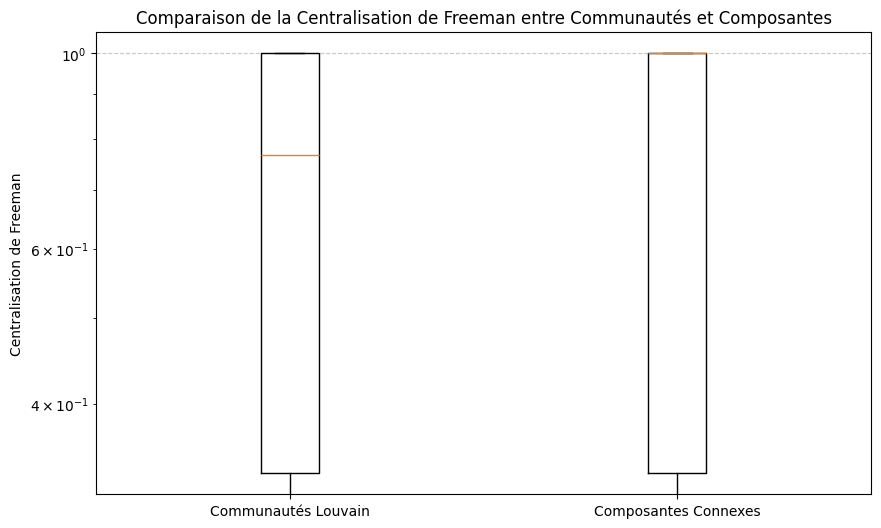

In [89]:
#Tracé des boites à moustaches des centralisations de Freeman
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
data_to_plot = [
    df_communities['freeman_centralization'].values,
    df_components['freeman_centralization'].values
]
plt.boxplot(data_to_plot, labels=['Communautés Louvain', 'Composantes Connexes'])
plt.ylabel("Centralisation de Freeman")
plt.title("Comparaison de la Centralisation de Freeman entre Communautés et Composantes")
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/var/folders/d9/yr1d00yj0w58yxqtc2zv6q580000gp/T/ipykernel_7279/2326633187.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


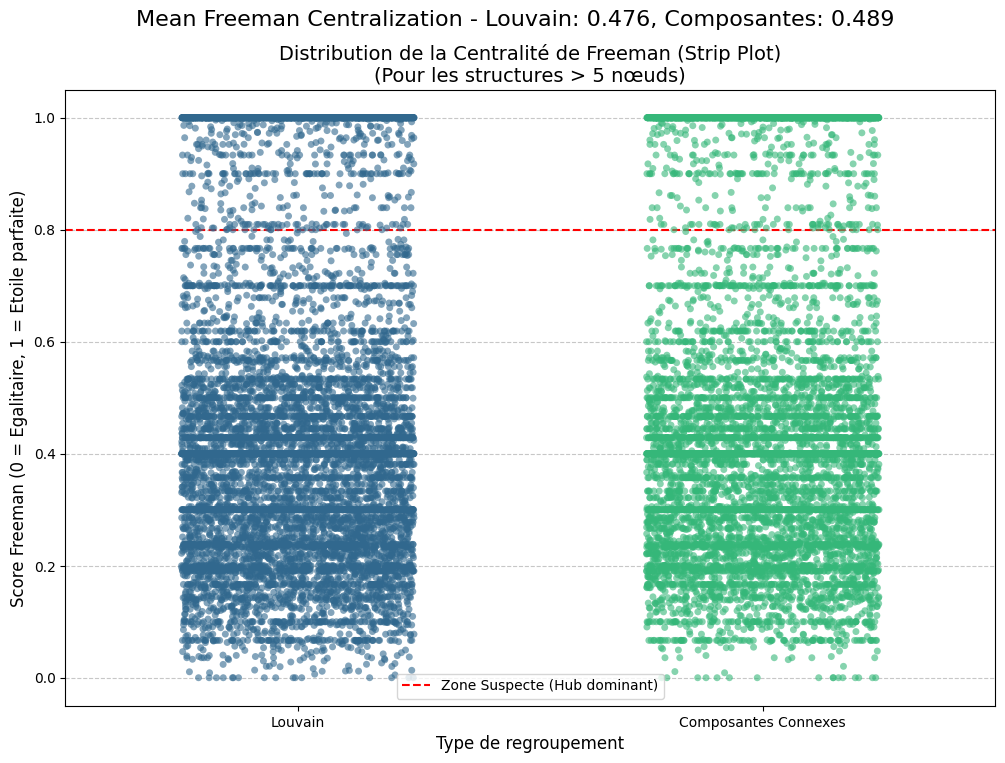

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. On prépare les données : on ajoute une colonne "Type" pour les distinguer
df_comm_plot = df_communities[['size', 'freeman_centralization']].copy()
df_comm_plot['Méthode'] = 'Louvain'

df_comp_plot = df_components[['size', 'freeman_centralization']].copy()
df_comp_plot['Méthode'] = 'Composantes Connexes'

# 2. On fusionne tout dans un seul tableau
df_all = pd.concat([df_comm_plot, df_comp_plot])

# 3. Filtrage (Optionnel mais recommandé)
# On enlève les toutes petites communautés (< 5 nœuds) qui font du bruit (souvent score 0 ou 1 trivial)
df_filtered = df_all[df_all['size'] > 5]

mean_freeman_louvain = df_filtered[df_filtered['Méthode'] == 'Louvain']['freeman_centralization'].mean()
mean_freeman_components = df_filtered[df_filtered['Méthode'] == 'Composantes Connexes']['freeman_centralization'].mean()

# --- LE GRAPHIQUE ---
plt.figure(figsize=(12, 8))

# Le Strip Plot : `jitter=True` étale les points horizontalement pour ne pas qu'ils s'empilent
# alpha=0.4 rend les points transparents pour voir la densité
sns.stripplot(
    data=df_filtered, 
    x='Méthode', 
    y='freeman_centralization', 
    jitter=0.25, 
    size=5,
    alpha=0.6,
    palette="viridis" # Ou "Set2", "Deep"
)

# Ajout des moyennes dans le titre
plt.suptitle(f"Mean Freeman Centralization - Louvain: {mean_freeman_louvain:.3f}, Composantes: {mean_freeman_components:.3f}", fontsize=16)
plt.title("Distribution de la Centralité de Freeman (Strip Plot)\n(Pour les structures > 5 nœuds)", fontsize=14)
plt.ylabel("Score Freeman (0 = Egalitaire, 1 = Etoile parfaite)", fontsize=12)
plt.xlabel("Type de regroupement", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ligne rouge pour marquer la zone "Suspecte"
plt.axhline(y=0.8, color='r', linestyle='--', label="Zone Suspecte (Hub dominant)")
plt.legend()

plt.show()


In [102]:


#Print d une valeur de freeman pour un nœud aléatoire
import random
if G.number_of_nodes() > 0:
    sample_node = random.choice(list(G.nodes()))
    node_comm_id = G.nodes[sample_node].get('Louvain_Community', None)
    if node_comm_id is not None and node_comm_id in Communities:
        node_subgraph = G.subgraph(Communities[node_comm_id])
        freeman_score, max_deg = calculate_freeman(node_subgraph)
        print(f"Le nœud échantillon {sample_node} appartient à la communauté {node_comm_id} avec un score de Freeman de {freeman_score:.4f} et un degré max de {max_deg}.")

Le nœud échantillon 97237 appartient à la communauté 2086 avec un score de Freeman de 0.2536 et un degré max de 36565.


In [ ]:
# Calcul du nb de deg 1
degree_one_count = sum(1 for n in G.nodes() if G.degree(n) == 1)
total_nodes = G.number_of_nodes()
proportion_degree_one = (degree_one_count / total_nodes) * 100 if total_nodes > 0 else 0
print(f"Proportion de nœuds de degré 1 dans le graphe complet : {proportion_degree_one:.2f}%")



Proportion de nœuds de degré 1 dans le graphe complet : 43.80%


NameError: name 'Communities' is not defined

Nombre de composantes connexes détectées : 33068


Proportion degré 1 par composante: 33068it [00:05, 5595.71it/s]


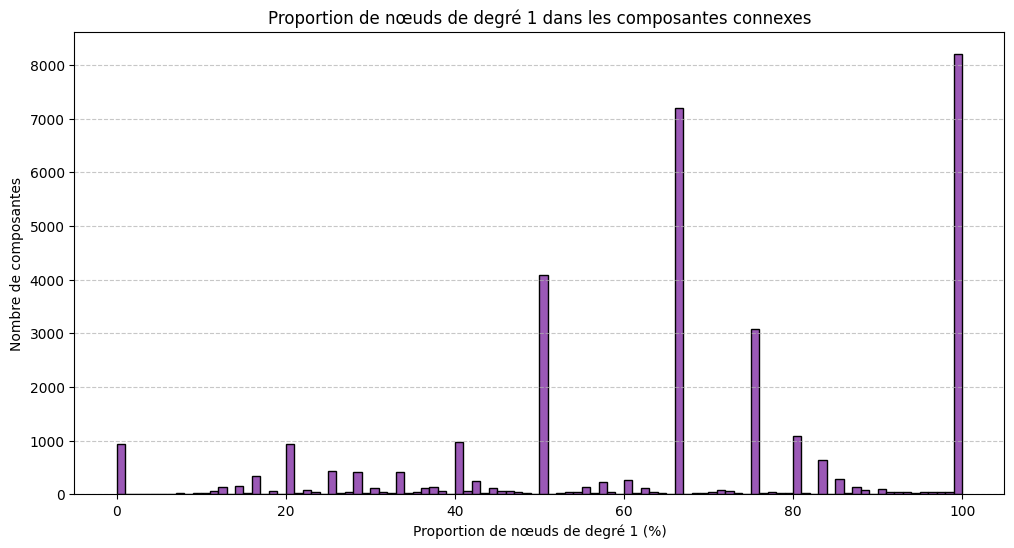

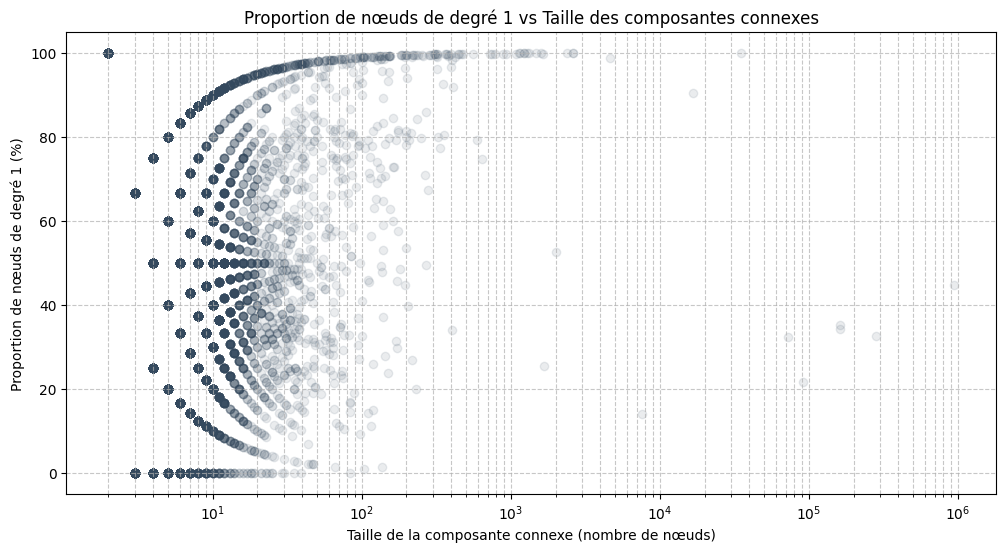

In [66]:
#Mesure de la proportion de noueds de degrés 1 dans chaque composante connexe
proportion_degree_comp = []
Components = list(nx.weakly_connected_components(G))
print("Nombre de composantes connexes détectées :", len(Components))
for i, component in tqdm(enumerate(Components), desc="Proportion degré 1 par composante"):
    subgraph = G.subgraph(component)
    degrees = dict(subgraph.degree())
    total_nodes = len(degrees)
    degree_one_nodes = sum(1 for deg in degrees.values() if deg == 1)
    proportion_degree_one = (degree_one_nodes / total_nodes) * 100 if total_nodes > 0 else 0
    proportion_degree_comp.append(proportion_degree_one)

#Visualisation des proportions de nœuds de degré 1 par composante connexe
plt.figure(figsize=(12, 6))
plt.hist(proportion_degree_comp, bins=100, color='#9b59b6', edgecolor='black')
plt.title("Proportion de nœuds de degré 1 dans les composantes connexes")
plt.xlabel("Proportion de nœuds de degré 1 (%)")
plt.ylabel("Nombre de composantes")
plt.grid(axis='y', linestyle='--', alpha=0.7)   
plt.show()

#Visualistation de la proportion en fonction de la taille des composantes connexes
component_sizes = [len(c) for c in Components]
plt.figure(figsize=(12, 6))
plt.scatter(component_sizes, proportion_degree_comp, alpha=0.1, color='#34495e')
plt.xscale('log')
#plt.yscale('log')
plt.title("Proportion de nœuds de degré 1 vs Taille des composantes connexes")
plt.xlabel("Taille de la composante connexe (nombre de nœuds)") 
plt.ylabel("Proportion de nœuds de degré 1 (%)")
plt.grid(True, which="both", ls="--", alpha=0.7)
plt.show()